# Example run of inverse problem.

## Preparing the notebook.

### Flags for autoreloading.

In [ ]:
AUTORELOAD = True
IS_EXT_LOADED = False

### Autoreload notebook.

In [ ]:
if AUTORELOAD:
    if not IS_EXT_LOADED:
        %load_ext autoreload
        IS_EXT_LOADED = True
    assert IS_EXT_LOADED
    %autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Importing the libraries.

In [ ]:
import sys
from typing import Literal, Type

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cdist
from scipy.special import softmax
import seaborn as sns
import torch
import yaml

from sc_exp_design.constants import DataFields, ParamsFields
from sc_exp_design.config import NeuralVelocityFieldConfig
from sc_exp_design.models import FlowMatching, TargetPredictionModel
from sc_exp_design.utils import set_reproducibility
from sc_exp_design.training.callbacks import MetricsCallBack, TrainingCallBacks


### Constants.

In [ ]:
BASE_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC"
PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_15-15-26/lively-smoke-29_FlowMatching.pkl"
TARGET_PREDICTION_MODEL_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl"
ANNOTATION_CONFIG_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/generative_modeling/conditional_flow_matching/config/annotation/default.yaml"

RANDOM_SEED = 42

### Importing Additional Modules.

In [ ]:
sys.path.insert(0, f"{BASE_DIR}/inverse/inverse_utils")
from forward_model import ForwardModel
from lambda_schedulers import ExponentialDecayScheduler
from loss_guidance import LossGuidedFlow

### Reading annotation config.

In [ ]:
with open(ANNOTATION_CONFIG_PATH, "r") as fb:
    annotation_dict = yaml.safe_load(fb)

### Setting seed for reproducibility.

In [ ]:
set_reproducibility(RANDOM_SEED)

### Retrieving the number of scatter columns.

In [ ]:
scatter_columns = annotation_dict["scatter_columns"]
n_scatter_feats = len(scatter_columns)
print(f"{n_scatter_feats=}")

n_scatter_feats=6


### Classes for handling restandardization.

In [ ]:
TensorParams = dict[Literal[ParamsFields.MEAN, ParamsFields.COVARIANCE], torch.Tensor]

class ModelParam(torch.nn.Module):
    def __init__(self, data: torch.Tensor, device: str = "cuda"):
        super().__init__()
        self.data = torch.nn.Parameter(data, requires_grad=True).to(device)

class BaseZNorm(torch.nn.Module):
    def __init__(self, params: TensorParams):
        super().__init__()
        self.params = torch.nn.ModuleDict(
            {
                ParamsFields.MEAN: ModelParam(params[ParamsFields.MEAN]),
                ParamsFields.COVARIANCE: ModelParam(params[ParamsFields.COVARIANCE]),
            }
        )

    @property
    def mean(self) -> torch.nn.Parameter:
        return self.params[ParamsFields.MEAN]

    @property
    def cov(self) -> torch.nn.Parameter:
        return self.params[ParamsFields.COVARIANCE]


class ZNorm(BaseZNorm):
    def __init__(self, params: TensorParams):
        super().__init__(params)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """"""
        return (x - self.params[ParamsFields.MEAN].data)/self.params[ParamsFields.COVARIANCE].data


class IZNorm(BaseZNorm):
    def __init__(self, params: TensorParams):
        super().__init__(params=params)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """"""
        return x*self.params[ParamsFields.COVARIANCE].data + self.params[ParamsFields.MEAN].data


class RescaledTargetPredictionModel(torch.nn.Module):
    def __init__(
        self,
        model: TargetPredictionModel,
        inv_params: IZNorm,
        fwd_params: ZNorm,
    ) -> None:
        """"""
        super().__init__()
        self.resc_model = torch.nn.ModuleDict(
            {
                "inv_params": inv_params,
                "fwd_params": fwd_params,
                "model": model,
            }
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """"""
        x = self.resc_model["inv_params"](x)
        x = self.resc_model["fwd_params"](x)
        return self.resc_model["model"](x)


### Utility function for predictions.

In [ ]:
def get_prediction_adata(
    idx,
    sample,
    X_channel,
    X_scatter,
    train_adata_fwd,
    val_adata_fwd,
    perturbation_id,
    nn_val,
    perturbation_obs_key,
    cell_state_rep,
    perturbation_reps,
):
    # concatenating with predictions
    x_channel = np.concatenate(
        (
            train_adata_fwd.obsm[cell_state_rep][:, :-n_scatter_feats],
            val_adata_fwd.obsm[cell_state_rep][:, :-n_scatter_feats],
            X_channel,
        ), axis=0
    )
    x_scatter = np.concatenate(
        (
            train_adata_fwd.obsm[cell_state_rep][:, -n_scatter_feats:],
            val_adata_fwd.obsm[cell_state_rep][:, -n_scatter_feats:],
            X_scatter,
        ), axis=0
    )

    # handling conditions
    conditions = np.concatenate(
        (
            train_adata_fwd.obsm[perturbation_id],
            val_adata_fwd.obsm[perturbation_id],
            np.repeat(sample[None], X_channel.shape[0], axis=0)
        )
    )
    unique_perts = np.unique(conditions, axis=0)
    perts_id = np.apply_along_axis(
        lambda e: np.where(
            np.all(
                unique_perts == e, axis=-1
            ))[0].item(),
        -1,
        conditions
    ).tolist()

    # retrieving the mask for current nearest neighbor
    train_cond_mask = np.all(np.isclose(train_adata_fwd.obsm[perturbation_id], nn_val, atol=1e-5, rtol=1e-3), axis=-1)

    # preparing the annotations
    obs = pd.DataFrame(
        {
            "dataset_type": [
                "in-distribution" for _ in range(len(train_adata_fwd))
            ] + [
                "ood" for _ in range(len(val_adata_fwd))
            ] + [
                "generated" for _ in range(len(X_channel))
            ],
            "is_generated": [
                False for _ in range(len(train_adata_fwd))
            ] + [
                False for _ in range(len(val_adata_fwd))
            ] + [
                True for _ in range(len(X_channel))
            ],
            "is_true_ood": [
                False for _ in range(len(train_adata_fwd))
            ] + [
                True for _ in range(len(val_adata_fwd))
            ] + [
                False for _ in range(len(X_channel))
            ],
            "is_true_nn_cond": train_cond_mask.tolist() + [
                False for _ in range(len(val_adata_fwd))
            ] + [
                False for _ in range(len(X_channel))
            ],
            perturbation_obs_key: perts_id
        }
    )
    obsm = {
        "X_scatter": x_scatter,
        perturbation_reps: conditions,
    }
    uns = {"sampled_pert": sample, "nn_vals": nn_val}
    var = pd.DataFrame(index=train_adata_fwd.var_names)

    # creating adata
    pred_adata_group = sc.AnnData(
        X=x_channel,
        obs=obs,
        obsm=obsm,
        var=var,
        uns=uns
    )

    # computing pcs, neighbors, umap
    sc.pp.pca(pred_adata_group)
    sc.pp.neighbors(pred_adata_group)
    sc.tl.umap(pred_adata_group)
    
    # storing the results
    print(f"AnnData created for prior sample {idx} -> {pred_adata_group}")
    return pred_adata_group

## Loading Pre-Trained Models.

### Cellular Response Prediction Model.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

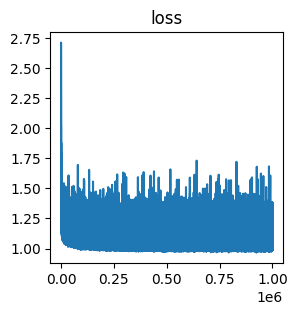

In [ ]:
perturbation_response_prediction_model = FlowMatching.load(
    PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH
)
perturbation_response_prediction_model.trainer.plot_training_logs()

### Retrieving z-standardization parameters for train data.

In [ ]:
X_channel_params_inv = perturbation_response_prediction_model.train_data.adata.uns["X_channel_params"]
X_scatter_params_inv = perturbation_response_prediction_model.train_data.adata.uns["X_scatter_params"]
print(f"{X_channel_params_inv.keys()=}, {X_scatter_params_inv.keys()=}")
params_inv = {
    ParamsFields.MEAN: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_inv[ParamsFields.MEAN],
                X_scatter_params_inv[ParamsFields.MEAN]
            ), axis=0
        )
    ),
    ParamsFields.COVARIANCE: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_inv["std"],
                X_scatter_params_inv["std"]
            ), axis=0
        )
    ),
}
izn = IZNorm(params_inv)
izn

X_channel_params_inv.keys()=dict_keys(['mean', 'std']), X_scatter_params_inv.keys()=dict_keys(['mean', 'std'])


IZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)

### Target Prediction Model.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

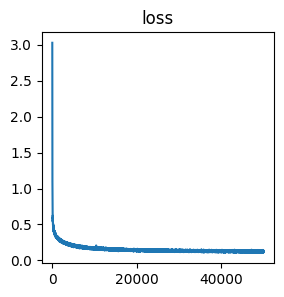

In [ ]:
target_prediction_model = TargetPredictionModel.load(
    TARGET_PREDICTION_MODEL_CHECKPOINT_PATH
)
target_prediction_model.target_predictor_trainer.plot_training_logs()

### Retrieving z-standardization parameters for train data.

In [ ]:
X_channel_params_fwd = target_prediction_model.train_data.adata.uns["X_channel_params"]
X_scatter_params_fwd = target_prediction_model.train_data.adata.uns["X_scatter_params"]
print(f"{X_channel_params_fwd.keys()}, {X_scatter_params_fwd.keys()}")
params_fwd = {
    ParamsFields.MEAN: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_fwd[ParamsFields.MEAN],
                X_scatter_params_fwd[ParamsFields.MEAN]
            ), axis=0
        )
    ),
    ParamsFields.COVARIANCE: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_fwd["std"],
                X_scatter_params_fwd["std"]
            ), axis=0
        )
    ),
}
zn = ZNorm(params_fwd)
zn

dict_keys(['mean', 'std']), dict_keys(['mean', 'std'])


ZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)

### Initializing rescaled target prediction model.

In [ ]:
g_model = RescaledTargetPredictionModel(
    target_prediction_model.target_prediction_model,
    inv_params=izn,
    fwd_params=zn
)

### Initializing forward model.

In [ ]:
forward_model = ForwardModel(
    forward_model=perturbation_response_prediction_model,
    target_prediction_model=g_model,
)

## Flow Prior.

### Retrieving the condition data.

In [ ]:
val_perturbation_data = next(iter(perturbation_response_prediction_model.validation_data[20].perturbation_data.values()))
train_perturbation_data = next(iter(perturbation_response_prediction_model.train_data.perturbation_data.values()))
print(f"{train_perturbation_data.shape=}, {val_perturbation_data.shape=}")

train_perturbation_data.shape=(93228325, 15), val_perturbation_data.shape=(47129, 15)


### Preparing train and validation adata.

In [ ]:
train_adata = sc.AnnData(
    X=train_perturbation_data,
    var=pd.DataFrame(index=annotation_dict["protocol_columns"])
)
val_adata = sc.AnnData(
    X=val_perturbation_data,
    var=pd.DataFrame(index=annotation_dict["protocol_columns"])
)
print(f"{train_adata=}, {val_adata=}")

train_adata=AnnData object with n_obs × n_vars = 93228325 × 15, val_adata=AnnData object with n_obs × n_vars = 47129 × 15


### Initializing the model.

In [ ]:
prior_flow = FlowMatching(
    flow_type="rectified",
    coupling_type="independent",
    generate_from_noise=True
)
prior_flow

### Preparing prior flow data.

In [ ]:
prior_flow.prepare_train_data(train_adata)
prior_flow.prepare_validation_data("validation", val_adata)

### Preparing velocity field configuration.

In [ ]:
vf_config = NeuralVelocityFieldConfig(
    train_adata.X.shape[-1],
    state_encoder_mlp_kwargs={
        "hidden_dims": (64, 64),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.ReLU,
        "final_activation_class": torch.nn.Identity,
    },
    encode_time=True,
    use_sinusoidal_time_features=True,
    time_encoder_mlp_kwargs={
        "hidden_dims": (32, 32),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.ReLU,
        "final_activation_class": torch.nn.Identity,
    },
    use_guidance=False,
    decoder_mlp_kwargs={
        "hidden_dims": (128, 128, 128),
        "use_batchnorm": False,
        "use_dropout": False,
        "activation_class": torch.nn.ReLU,
        "final_activation_class": torch.nn.Identity,
    },
    conditioning_type="resnet"
)


With self.use_guidance=False an unguided flow model will be initialized, thus the settings for the condition encoder will be ignored.


### Initializing model.

In [ ]:
optimizer_kwargs = {"lr": 1e-4}
prior_flow.prepare_model(
    vf_config,
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs=optimizer_kwargs
)

### Set up callbacks.

In [ ]:
metrics_cb = MetricsCallBack(["energy_distance", "r_squared"])
cb = TrainingCallBacks([metrics_cb])

### Training the model.

retrieving indices


Loss: 1.3210: 100%|██████████| 100000/100000 [07:03<00:00, 236.00it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

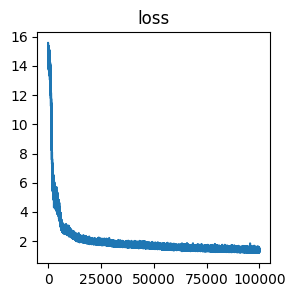

In [ ]:
prior_flow.train(
    num_training_steps=100_000,
    valid_freq=50_000,
    train_batch_size=4096,
    validation_batch_size=10_000,
    num_grad_accumulation_steps=20,
    callbacks=cb
)
prior_flow.trainer.plot_training_logs()


### Sample from the condition prior.

In [ ]:
num_prior_samples = 50
num_time_steps = 100
solver_kwargs = {"method":"euler"}
prior_samples = prior_flow.predict(
    {},
    batch_size=num_prior_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
prior_samples = np.maximum(prior_samples, 0)
print(prior_samples.shape)

(50, 15)


### Subsampling train data for efficiency.

In [ ]:
n_train_samples_to_retain = 100_000
train_adata_subset = sc.pp.sample(train_adata, n=n_train_samples_to_retain, copy=True)
train_adata_subset

AnnData object with n_obs × n_vars = 100000 × 15

### Visualize prior samples.

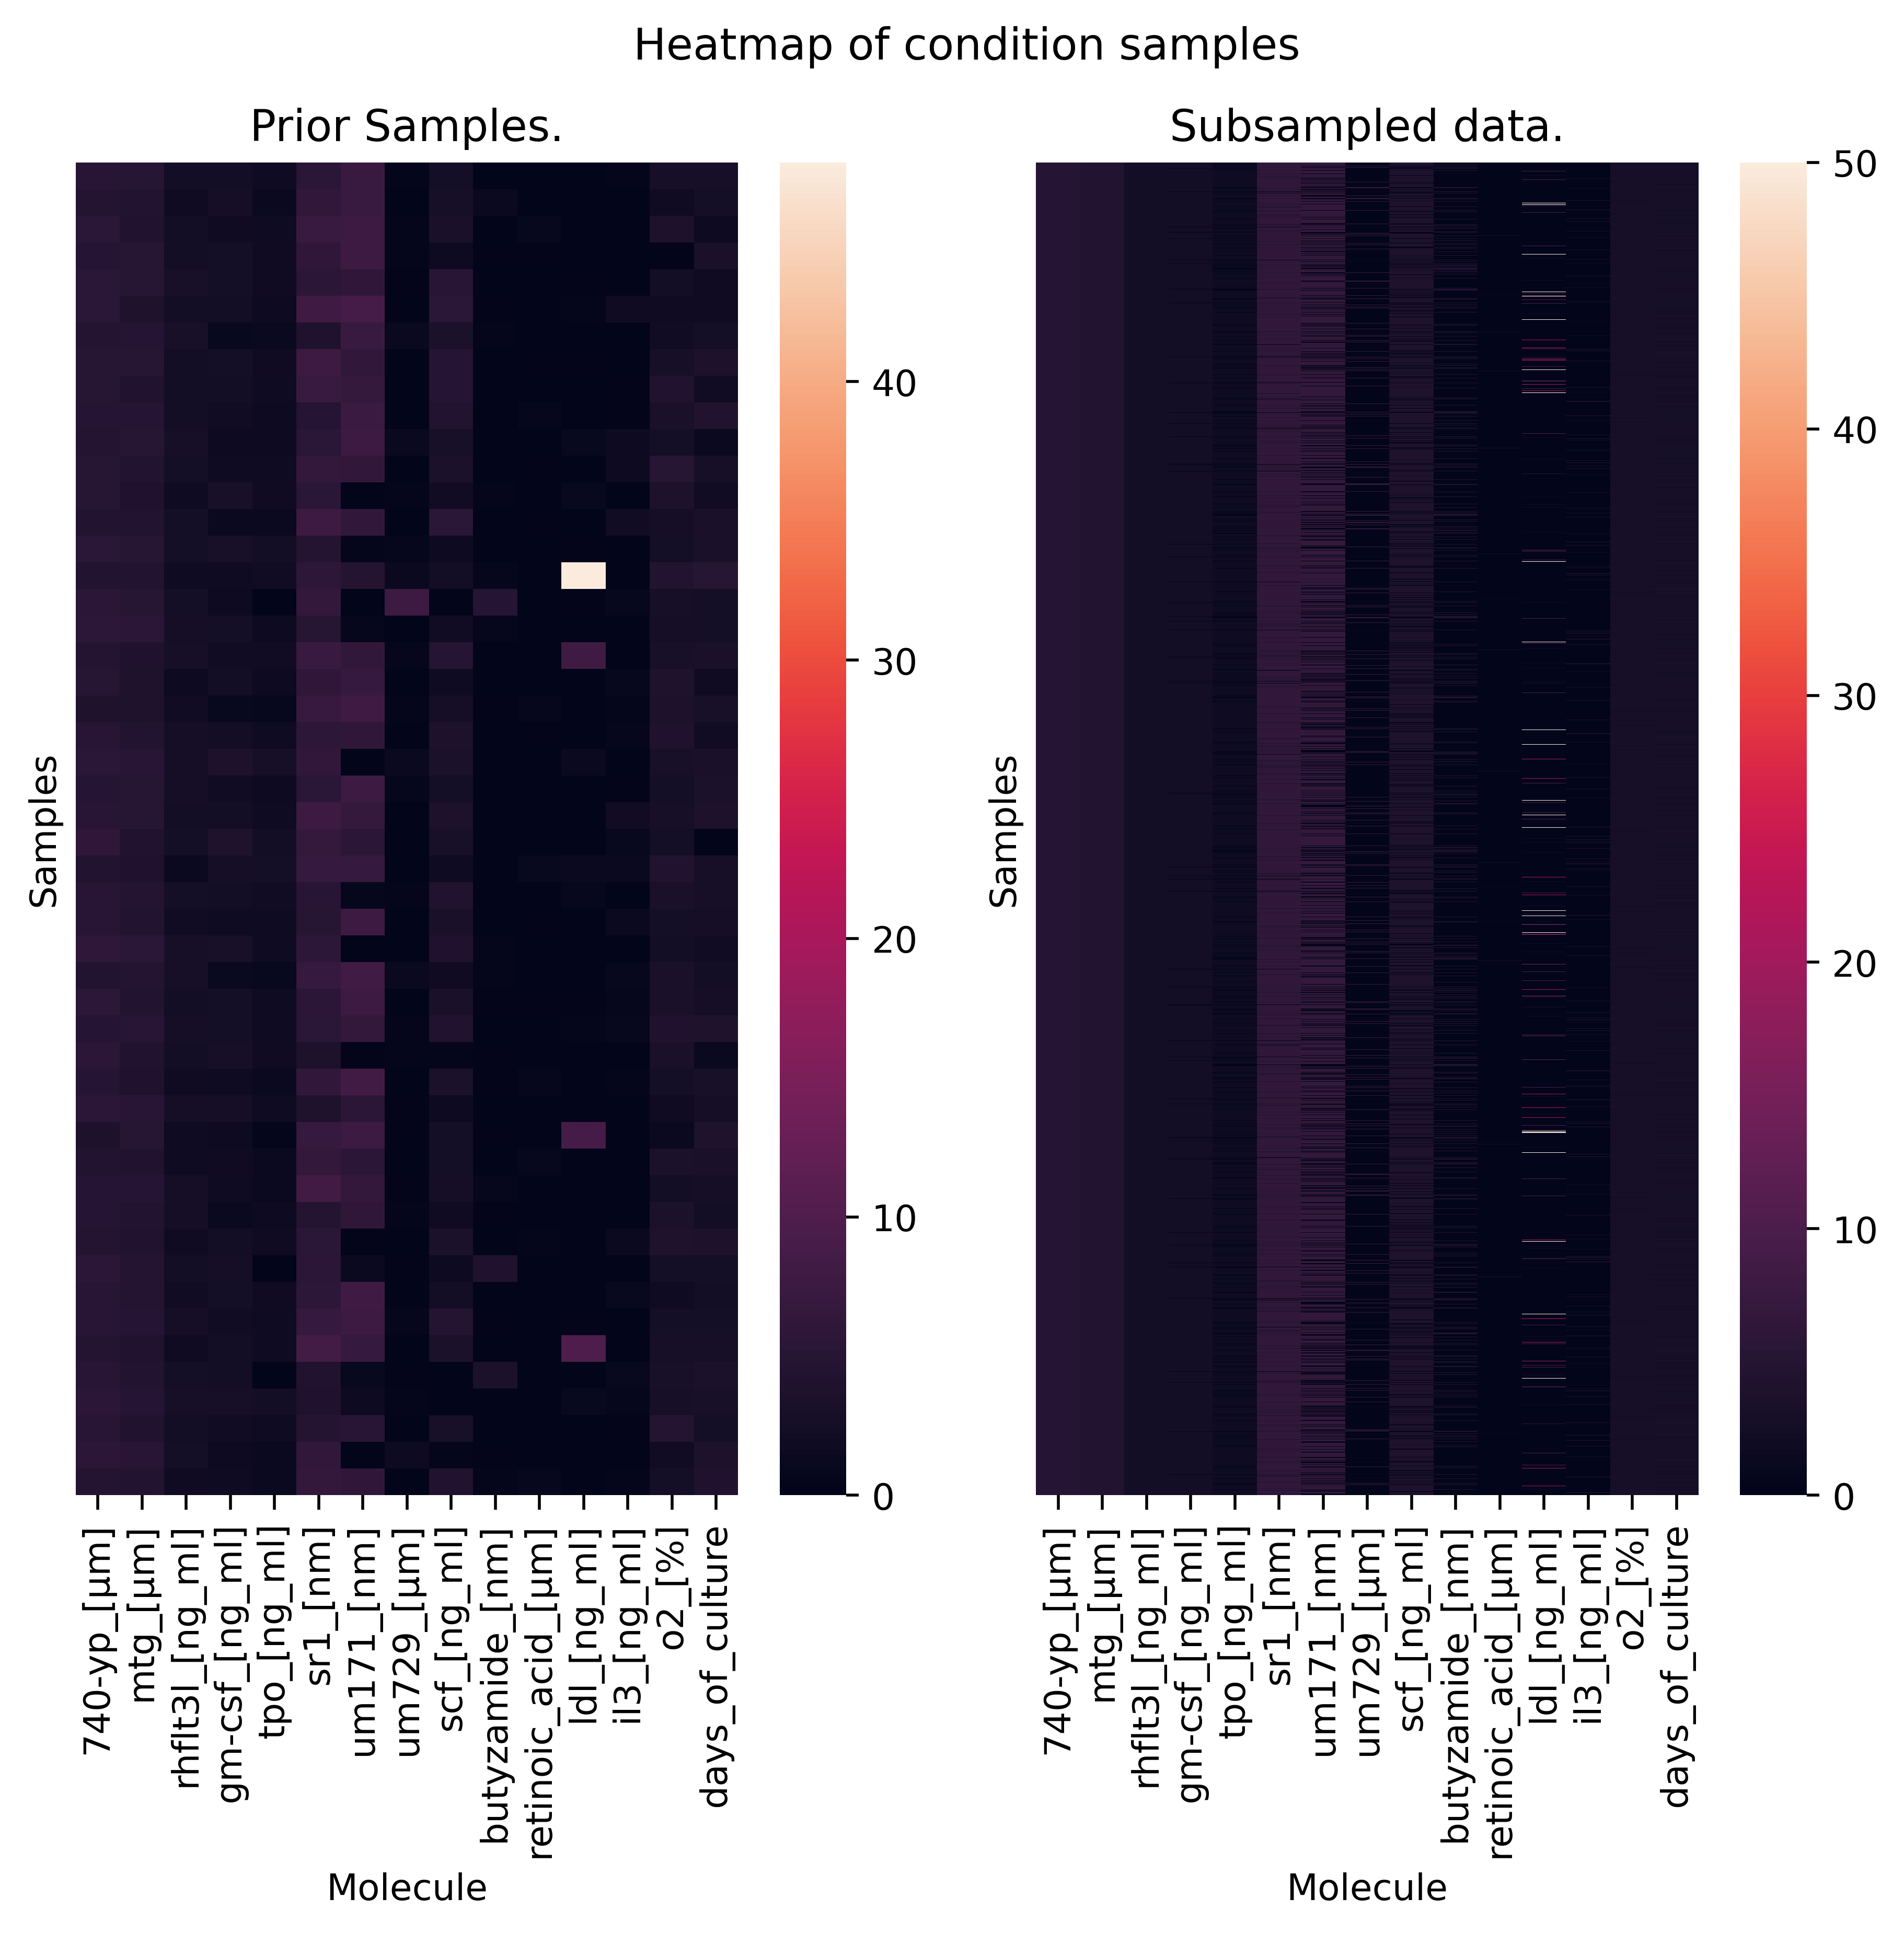

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(7.5, 7.5), dpi=500)
fig.suptitle("Heatmap of condition samples")
sns.heatmap(
    prior_samples,
    annot=False,
    xticklabels=train_adata.var_names,
    ax=ax[0]
); ax[0].tick_params("x", rotation=90, size=4); ax[0].set_title("Prior Samples."); ax[0].set_yticks([])
ax[0].set_xlabel("Molecule"); ax[0].set_ylabel("Samples")  
sns.heatmap(
    train_adata_subset.X,
    annot=False,
    xticklabels=train_adata.var_names,
    ax=ax[1]
); ax[1].tick_params("x", rotation=90, size=4); ax[1].set_title("Subsampled data."); ax[1].set_yticks([])
ax[1].set_xlabel("Molecule"); ax[1].set_ylabel("Samples")
fig.tight_layout(); fig.show()

### Plotting the mean and standard deviation over each axes.

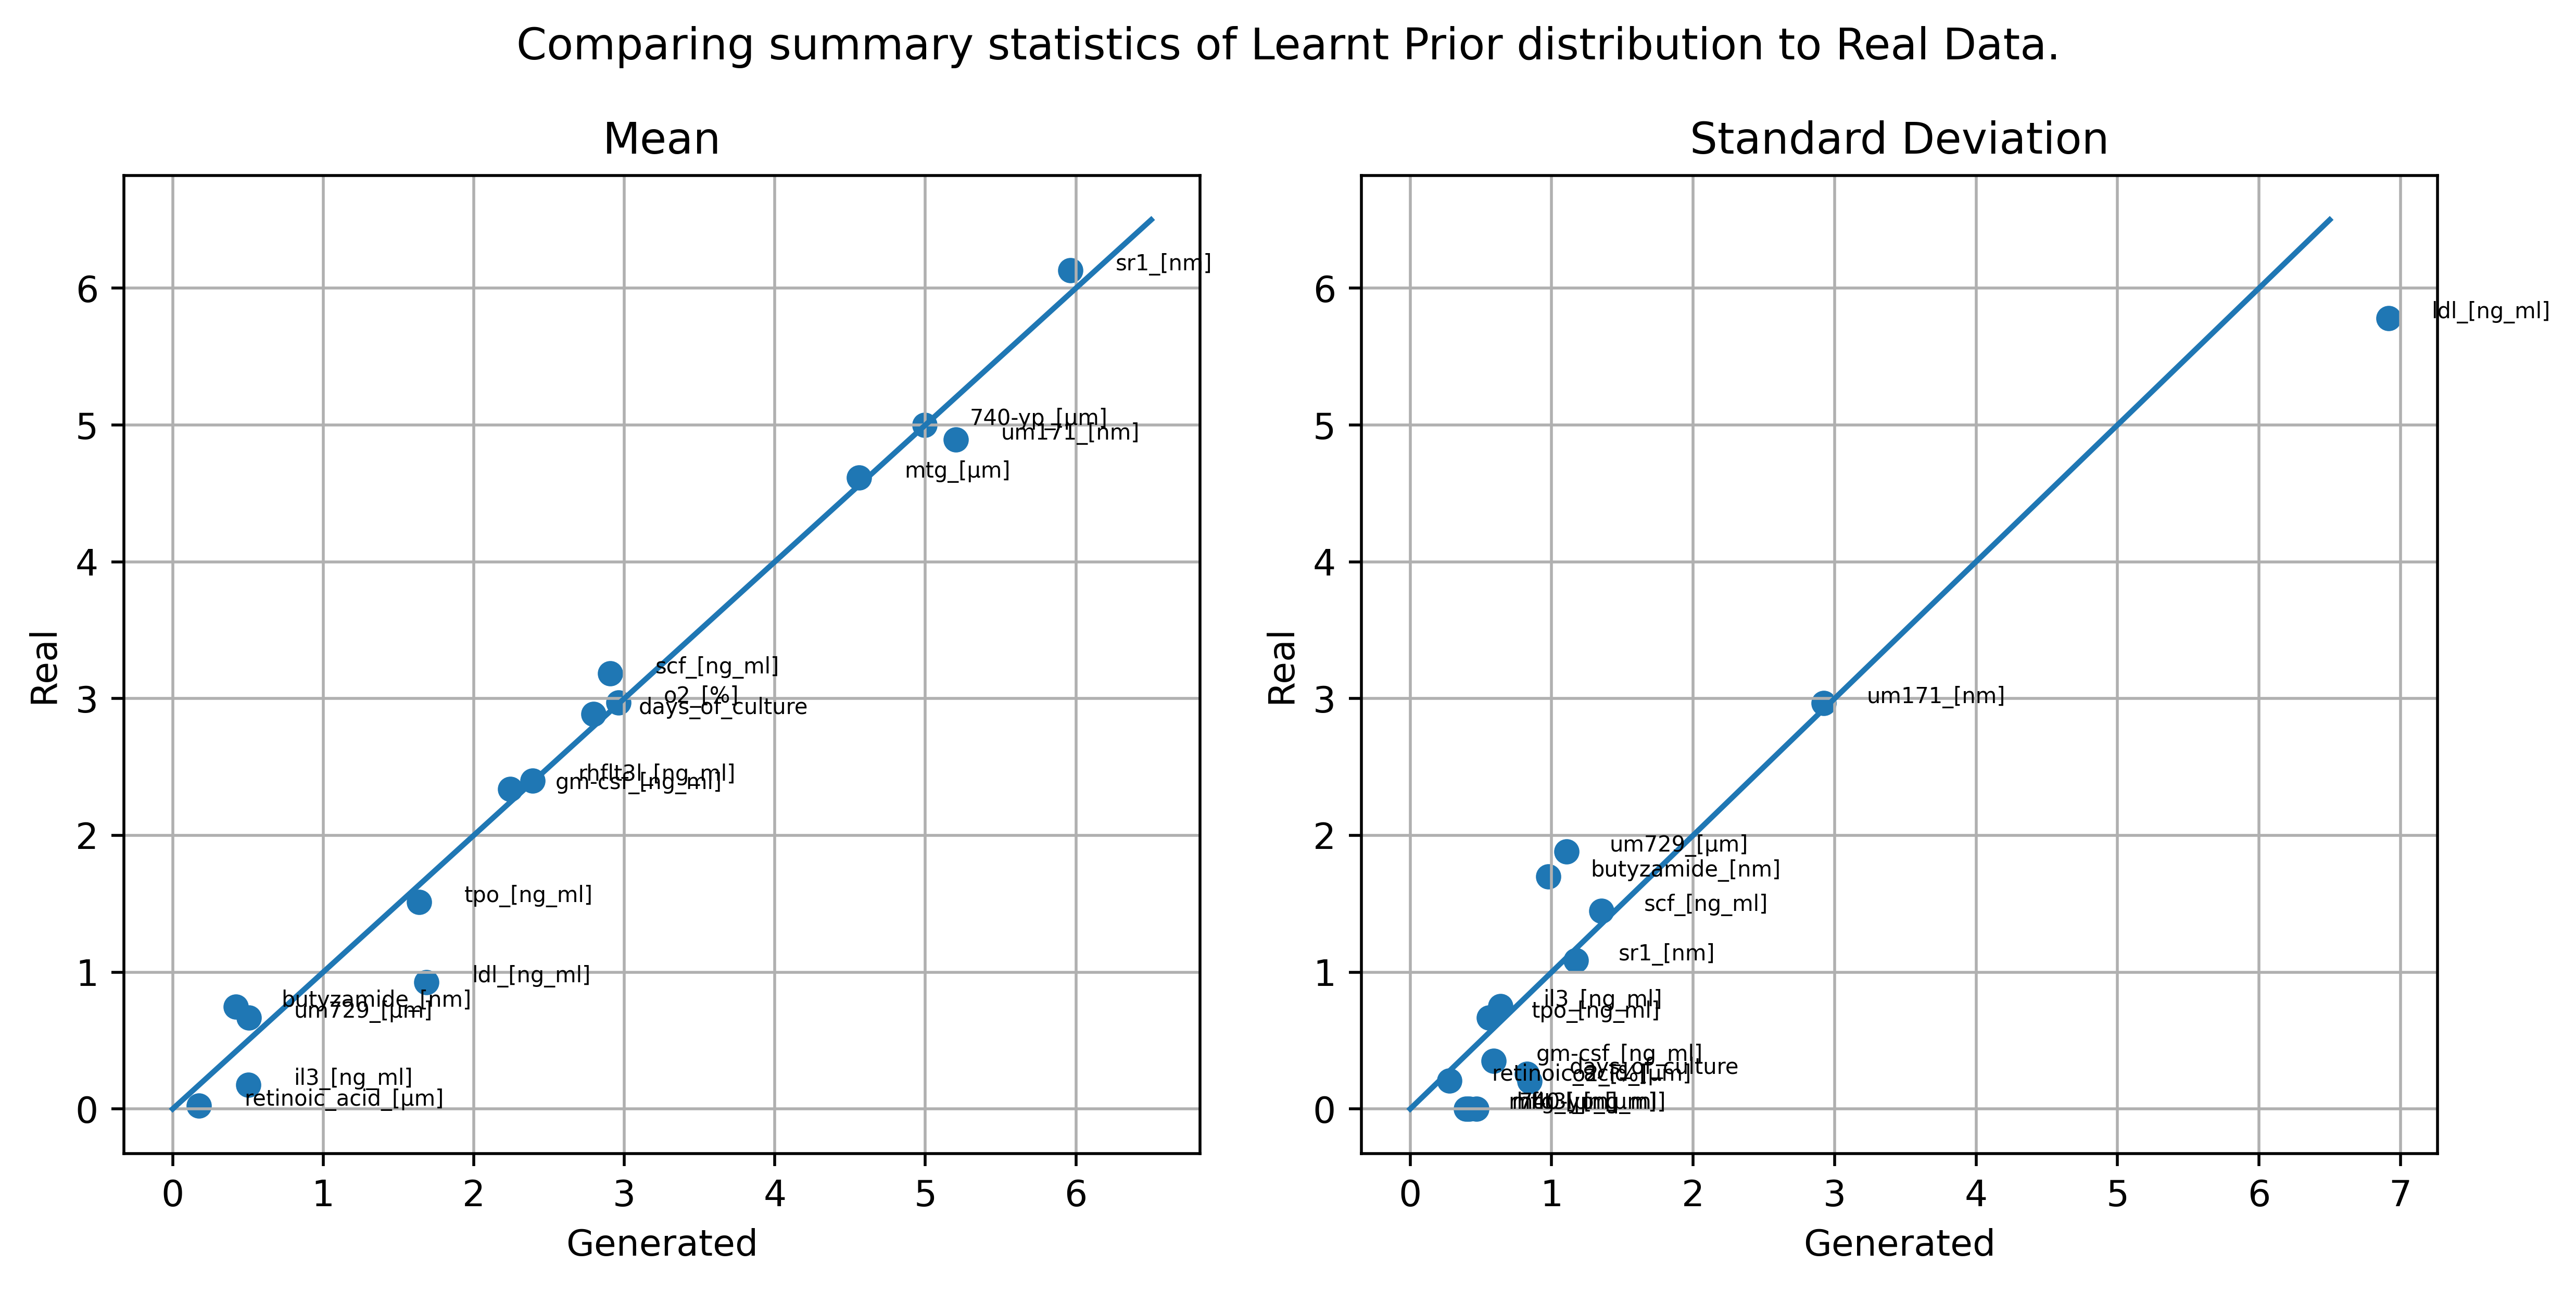

In [ ]:
# mean
prior_mean = prior_samples.mean(0)
real_mean = train_adata_subset.X.mean(0)

# standard deviation
prior_std = prior_samples.std(0)
real_std = train_adata_subset.X.std(0)

# initializing plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=500)
fig.suptitle("Comparing summary statistics of Learnt Prior distribution to Real Data.")

# contructing linear space
linspace = np.linspace(0.0, 6.5, 100)

# plotting mean
ax[0].scatter(prior_mean, real_mean); ax[0].grid(True)
ax[0].set_title("Mean"); ax[0].set_xlabel("Generated"); ax[0].set_ylabel("Real")
ax[0].plot(linspace, linspace)
yoffset = 0.0
xoffset = 0.3
for i, txt in enumerate(train_adata.var_names):
    ax[0].annotate(txt, (prior_mean[i] + xoffset, real_mean[i] + yoffset), size=6)

# plotting standard deviation
ax[1].scatter(prior_std, real_std); ax[1].grid(True)
ax[1].set_title("Standard Deviation"); ax[1].set_xlabel("Generated"); ax[1].set_ylabel("Real")
for i, txt in enumerate(train_adata.var_names):
    ax[1].annotate(txt, (prior_std[i] + xoffset, real_std[i] + yoffset), size=6)
ax[1].plot(linspace, linspace)

fig.tight_layout(); fig.show()

### Prior Predictive Checks with forward model.

In [ ]:
n_fwd_samples = 500
perturbation_reps = next(iter(perturbation_response_prediction_model.train_data.data.perturbation_covariates))

# forward pass
pred_dict = forward_model.predict(
    {
        DataFields.PERTURBATION_DATA: {
            perturbation_reps: torch.from_numpy(prior_samples).float().to(perturbation_response_prediction_model.device)
        }
    },
    num_samples=n_fwd_samples
)
X_hat = pred_dict.pop("predicted_states").detach().cpu().numpy()
G_logits = pred_dict.pop("target_prediction_data")["cell_type"].detach().cpu().numpy()

# splitting channel and scatter features
X_channel = X_hat[:, :, :-n_scatter_feats]
X_scatter = X_hat[:, :, -n_scatter_feats:]
print(f"{X_hat.shape=}, {X_channel.shape=}, {X_scatter.shape=}")

X_hat.shape=(500, 50, 27), X_channel.shape=(500, 50, 21), X_scatter.shape=(500, 50, 6)


### Subsampling train and validation data.

In [ ]:
n_train_cells = 50_000
n_val_cells = 10_000
train_adata_fwd = sc.pp.sample(
    perturbation_response_prediction_model.train_data.adata,
    n=n_train_cells,
    copy=True
)
val_adata_fwd = sc.pp.sample(
    next(iter(perturbation_response_prediction_model.validation_data.values())).adata,
    n=n_val_cells,
    copy=True
)
print(f"{train_adata_fwd=}, {val_adata_fwd=}")

train_adata_fwd=AnnData object with n_obs × n_vars = 50000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one

### Retrieving NN (in subsampled data) for each prior sample.

In [ ]:
perturbation_id = "condition_concat"
unique_protocol_conditions = np.unique(
    train_adata_fwd.obsm[perturbation_id], axis=0
)
D = cdist(prior_samples, unique_protocol_conditions)
nn_idxs = D.argmin(1)
nn_vals = np.empty_like(prior_samples)
for idx in range(num_prior_samples):
    nn_vals[idx] = unique_protocol_conditions[nn_idxs[idx]]
print(f"{unique_protocol_conditions.shape=}, {D.shape=}, {nn_vals.shape=}")

unique_protocol_conditions.shape=(115, 15), D.shape=(50, 115), nn_vals.shape=(50, 15)


### Visualizing NN from subsampled adata.

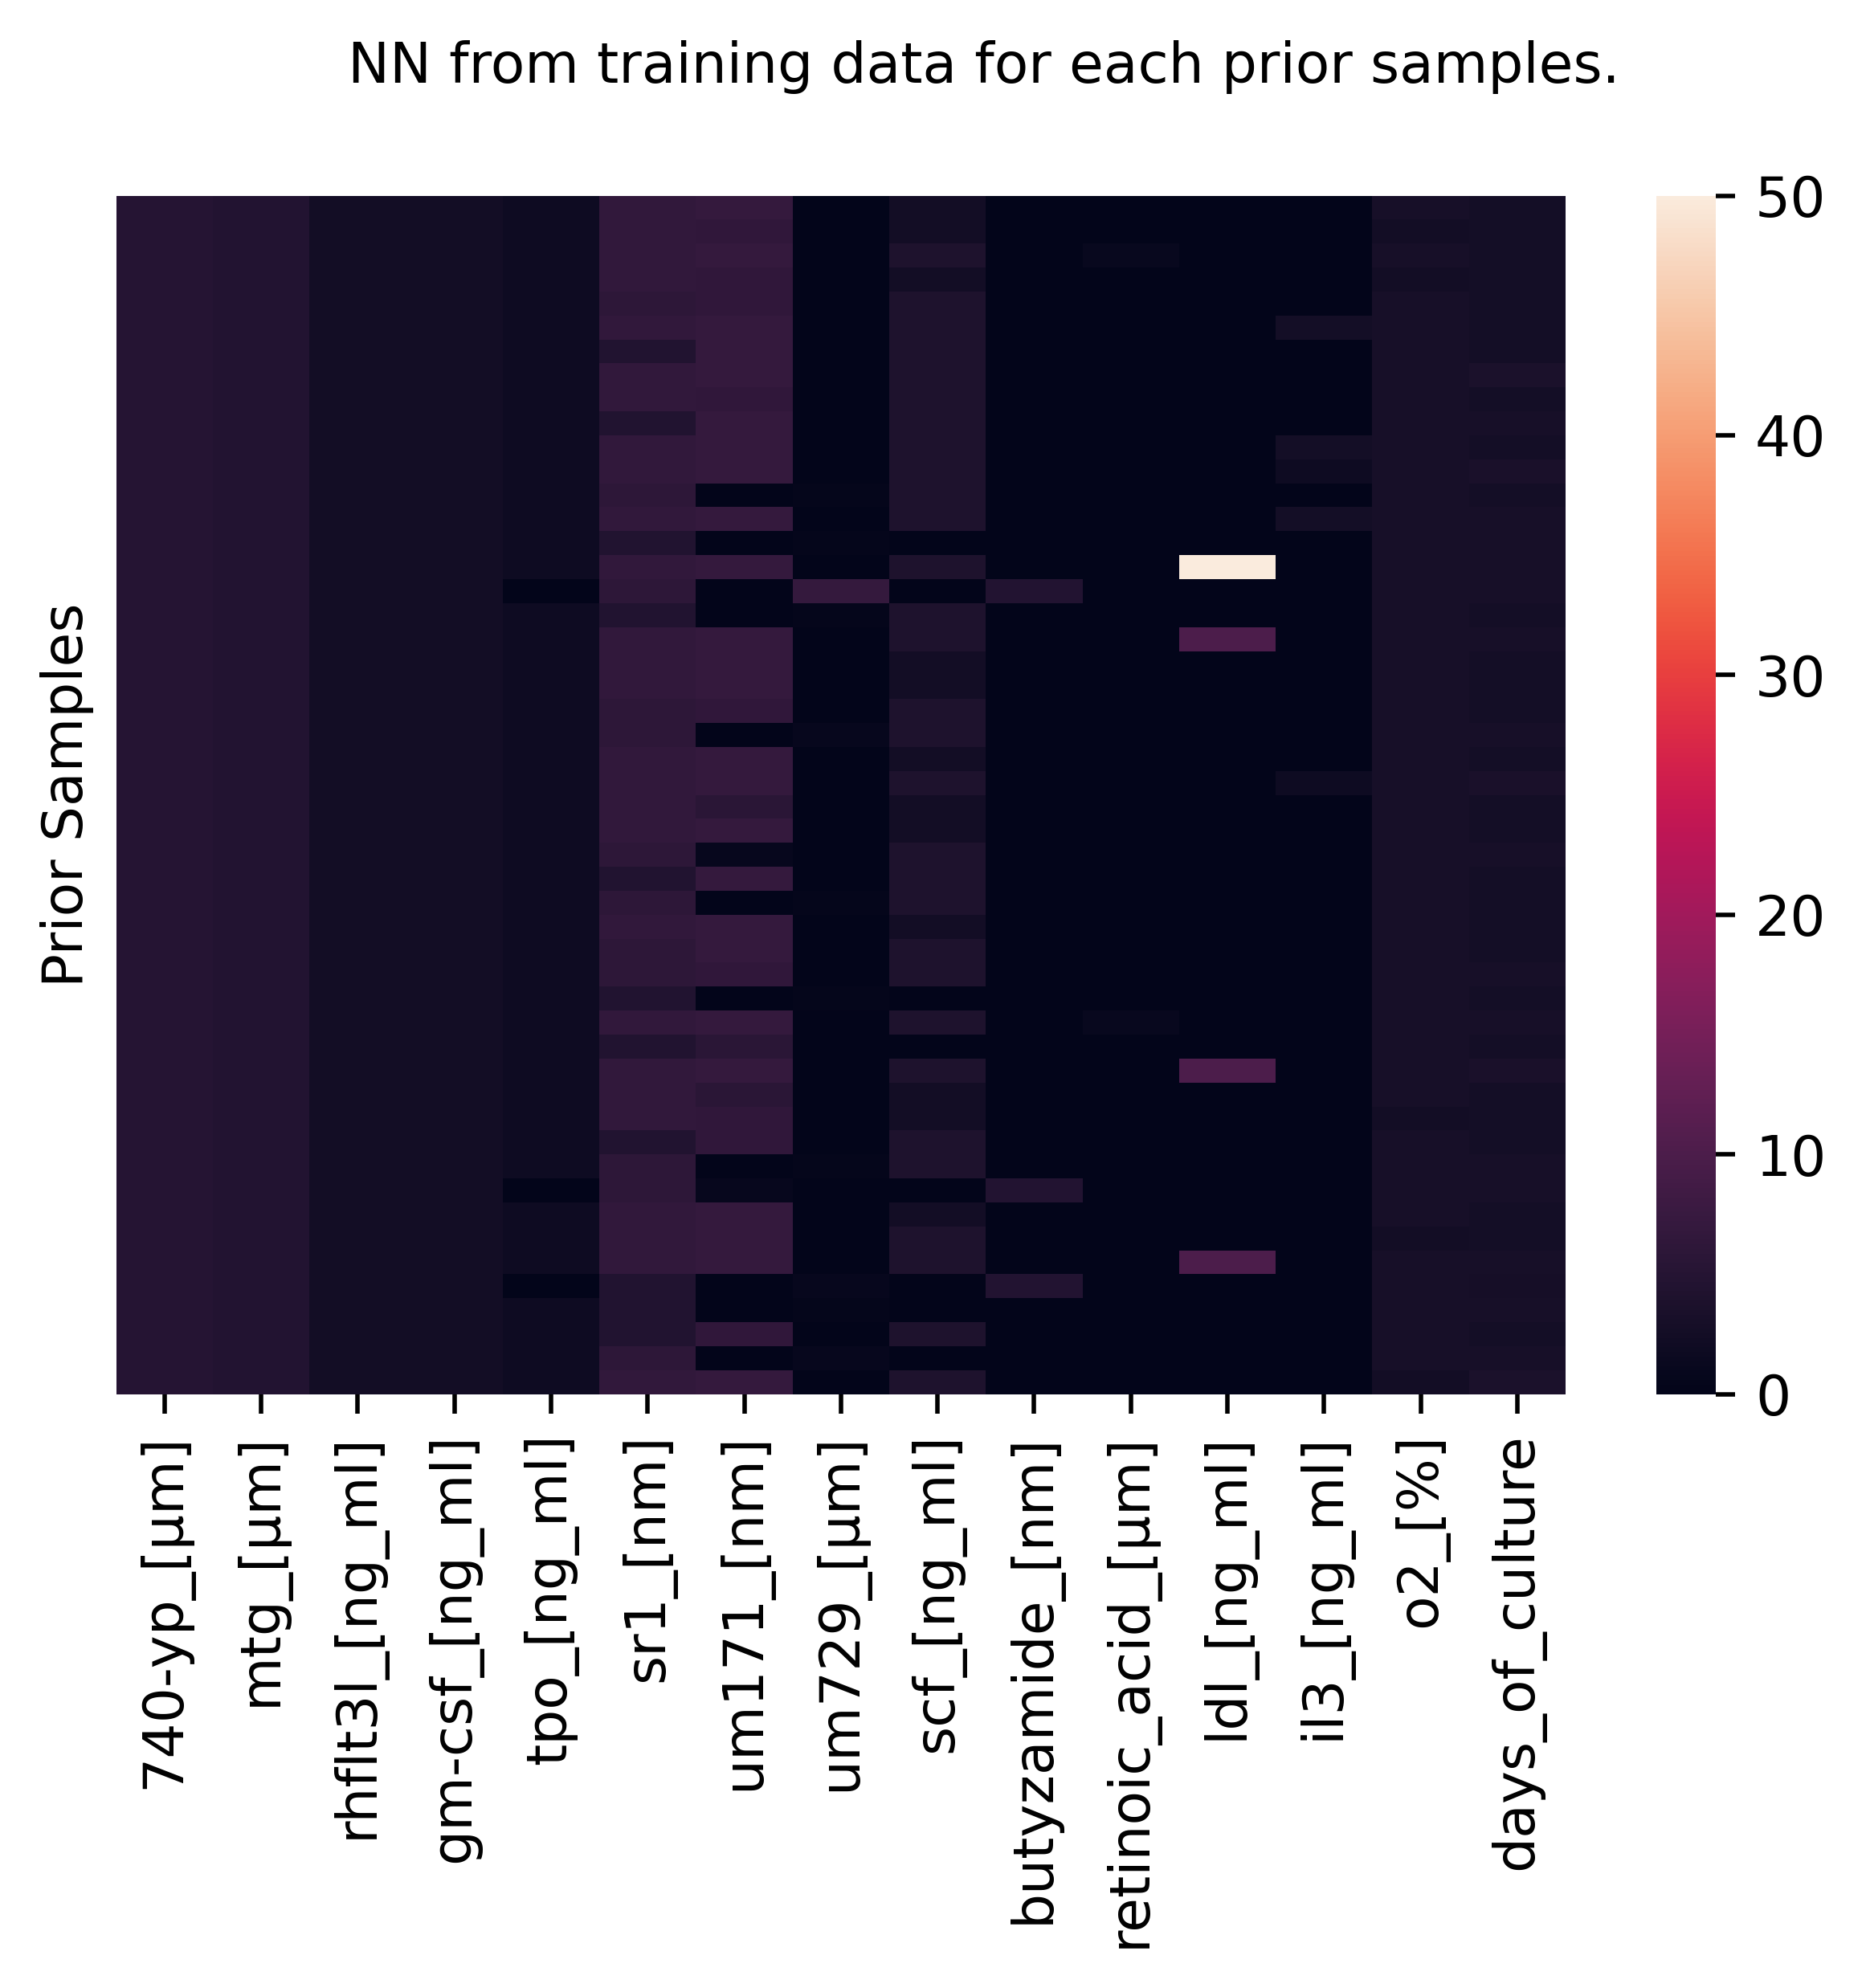

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=500)
fig.suptitle("NN from training data for each prior samples.", size=10)
sns.heatmap(nn_vals, annot=False, ax=ax, xticklabels=train_adata.var_names)
ax.set_yticks([]); ax.set_yticks([])
ax.set_ylabel("Real Samples"); ax.set_ylabel("Prior Samples")
fig.tight_layout(); fig.show()

### Visualizing distances.

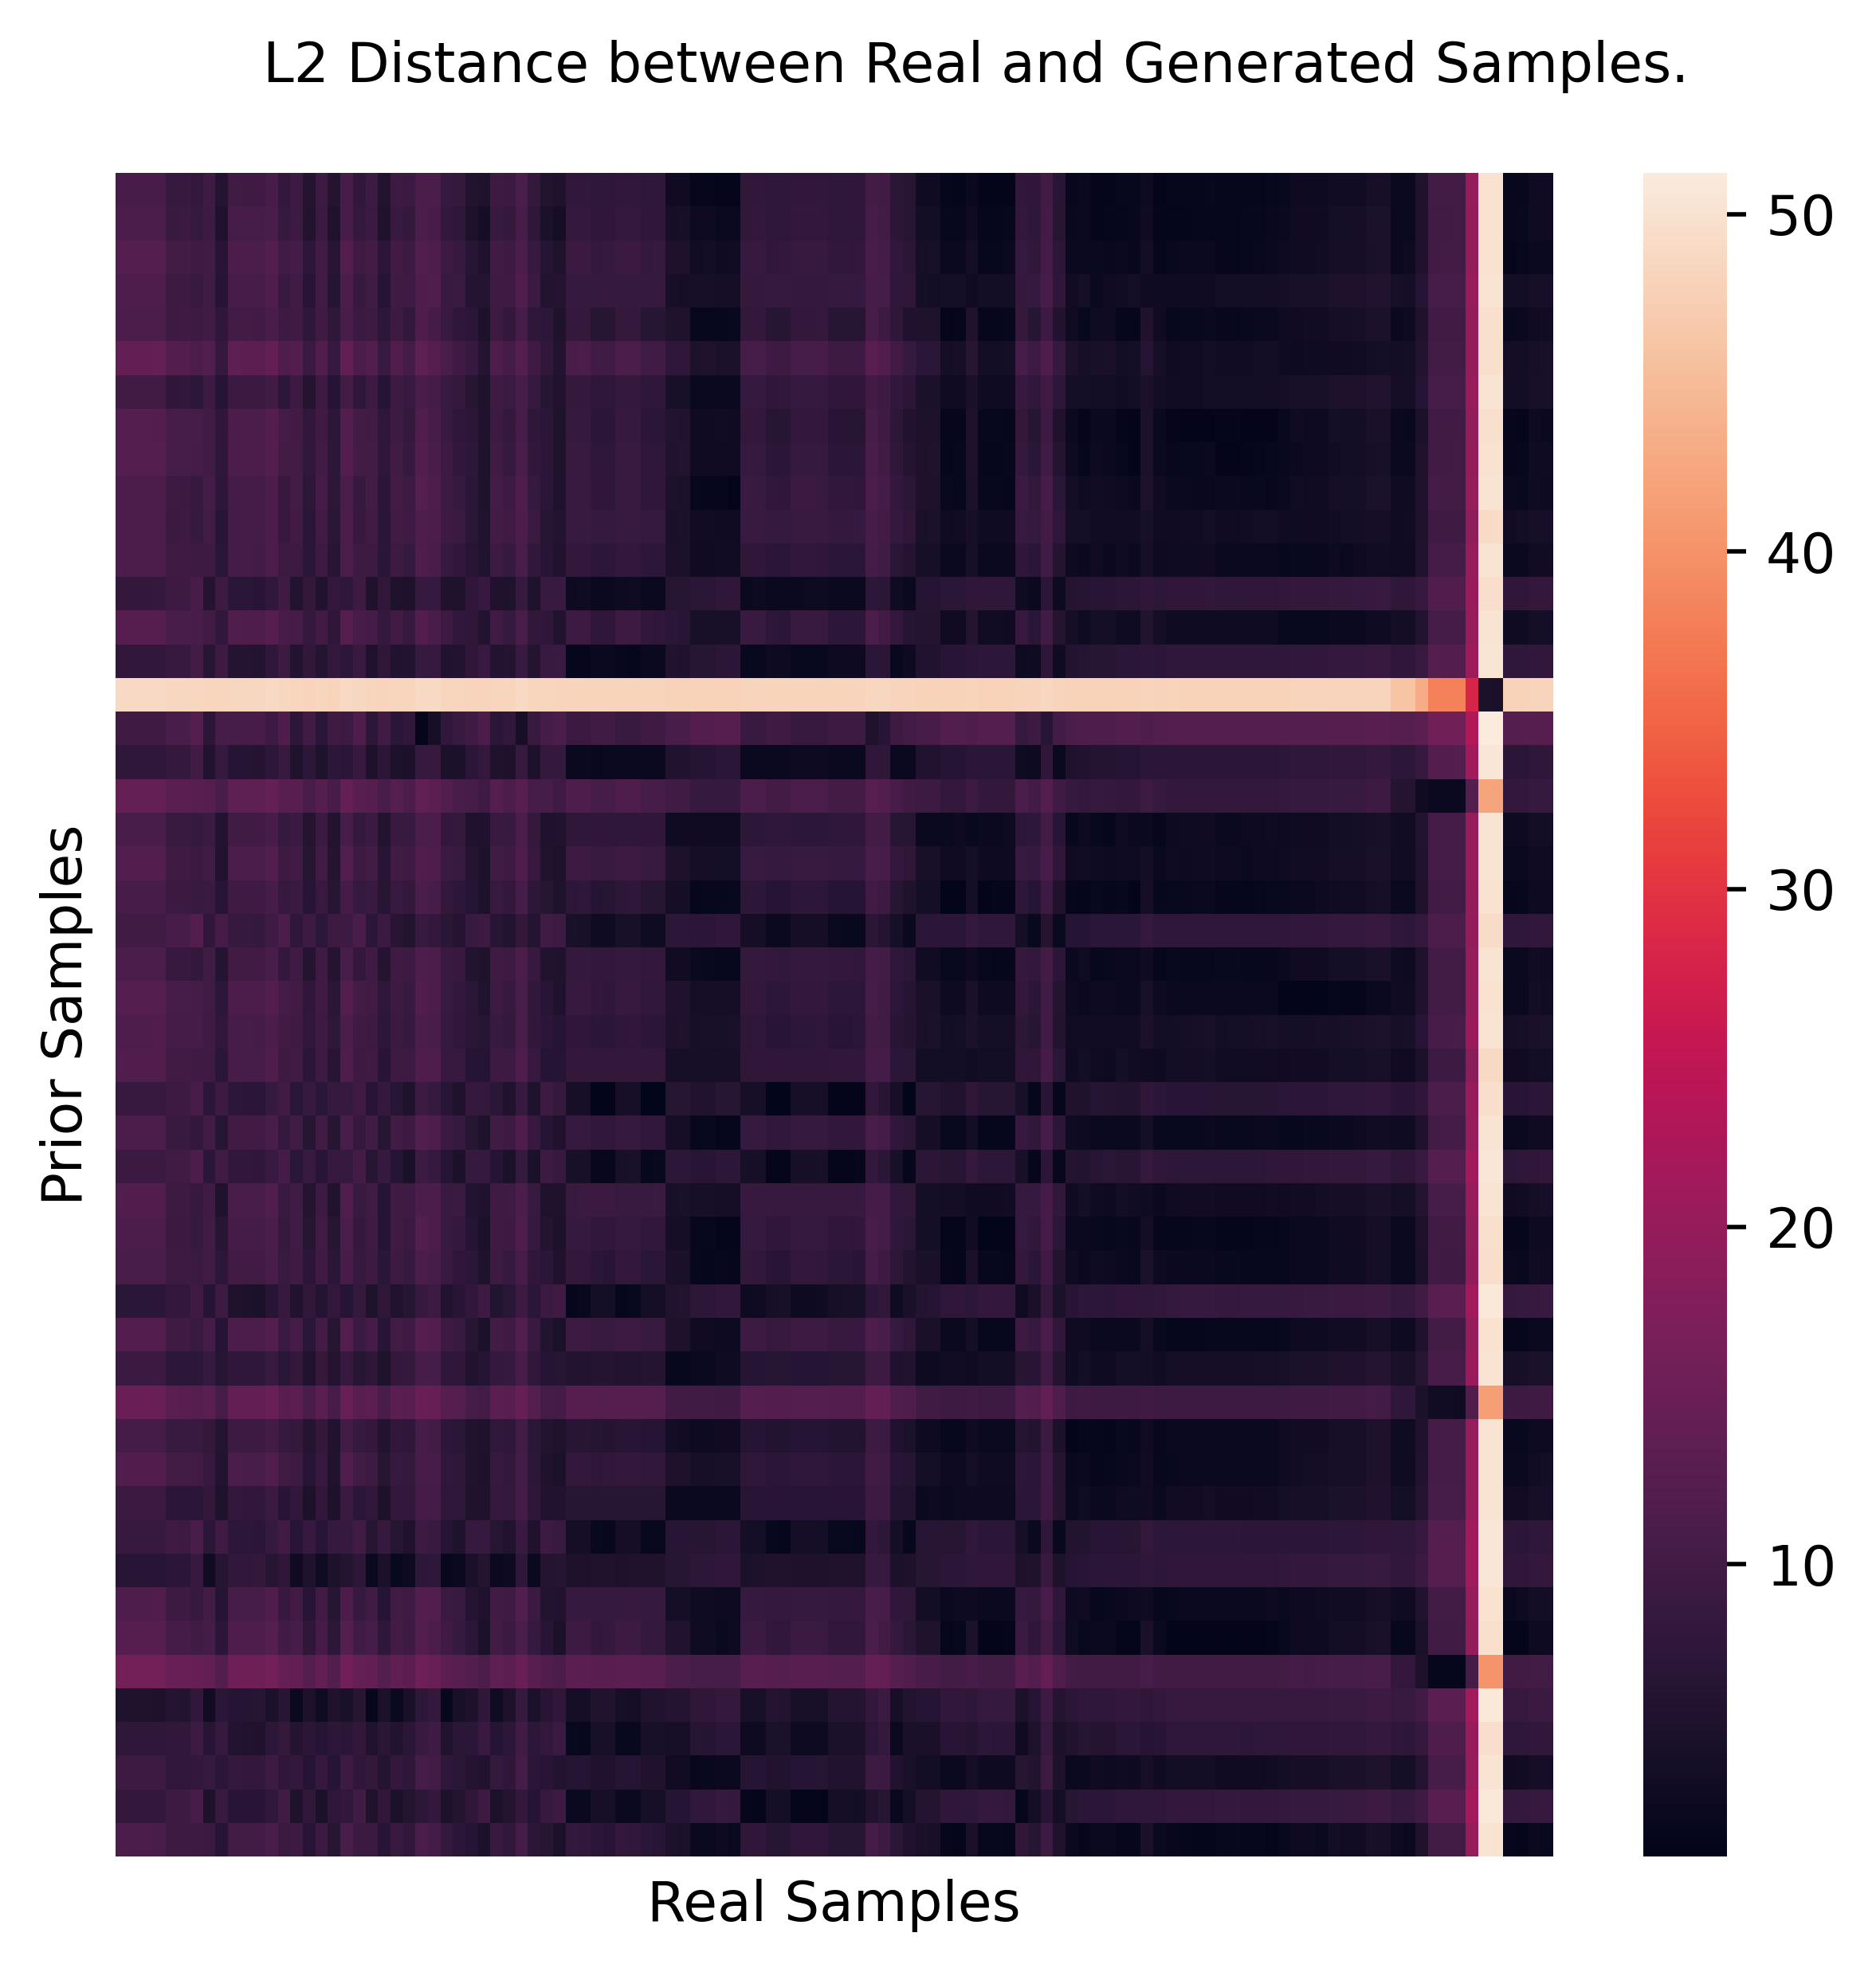

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=500)
fig.suptitle("L2 Distance between Real and Generated Samples.", size=10)
sns.heatmap(D, annot=False, ax=ax)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Real Samples"); ax.set_ylabel("Prior Samples")
fig.tight_layout(); fig.show()

### Retrieving prior samples with minimal NN distances.

In [ ]:
# defining the number of prior samples for which we will
# visualize the queries from the forward model
num_prior_samples_to_visualize = 3

# choosing the samples with the minimum distance to the NN 
# in the real data and retrieving the corresponding real protocol
D_min = D.min(1)
min_idxs_all = np.argsort(D_min)
min_idxs = min_idxs_all[:num_prior_samples_to_visualize]

### Plotting the UMAP of the generated.

In [ ]:
# storing the results
cond2adata = {}

# defining keys for the anndata
perturbation_obs_key = "protocol_id"
cell_state_rep = "X_channel_standardized+X_scatter_standardized"

# iterating over the closest samples 
for idx in min_idxs:
    # slicing for current condition
    sample = prior_samples[idx]

    x_channel = X_channel[:, idx]
    x_scatter = X_scatter[:, idx]
    nn_val = nn_vals[idx]
    cond2adata[idx] = get_prediction_adata(
        idx,
        sample,
        x_channel,
        x_scatter,
        train_adata_fwd,
        val_adata_fwd,
        perturbation_id,
        nn_val,
        perturbation_obs_key,
        cell_state_rep,
        perturbation_reps,
    )

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


AnnData created for prior sample 43 -> AnnData object with n_obs × n_vars = 60500 × 21
    obs: 'dataset_type', 'is_generated', 'is_true_ood', 'is_true_nn_cond', 'protocol_id'
    uns: 'sampled_pert', 'nn_vals', 'pca', 'neighbors', 'umap'
    obsm: 'X_scatter', 'feats_condition_concat_condition_concat', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData created for prior sample 24 -> AnnData object with n_obs × n_vars = 60500 × 21
    obs: 'dataset_type', 'is_generated', 'is_true_ood', 'is_true_nn_cond', 'protocol_id'
    uns: 'sampled_pert', 'nn_vals', 'pca', 'neighbors', 'umap'
    obsm: 'X_scatter', 'feats_condition_concat_condition_concat', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData created for prior sample 27 -> AnnData object with n_obs × n_vars = 60500 × 21
    obs: 'dataset_type', 'is_generated', 'is_true_ood', 'is_true_nn_cond', 'protocol_id'
    uns: 'sampled_pert', 'nn_vals', 'pca', 'neighbors', 'umap'
    obsm: 'X_scatter', 'feats_condition_concat_condition_concat', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


### Visualizing the sampled protocols.

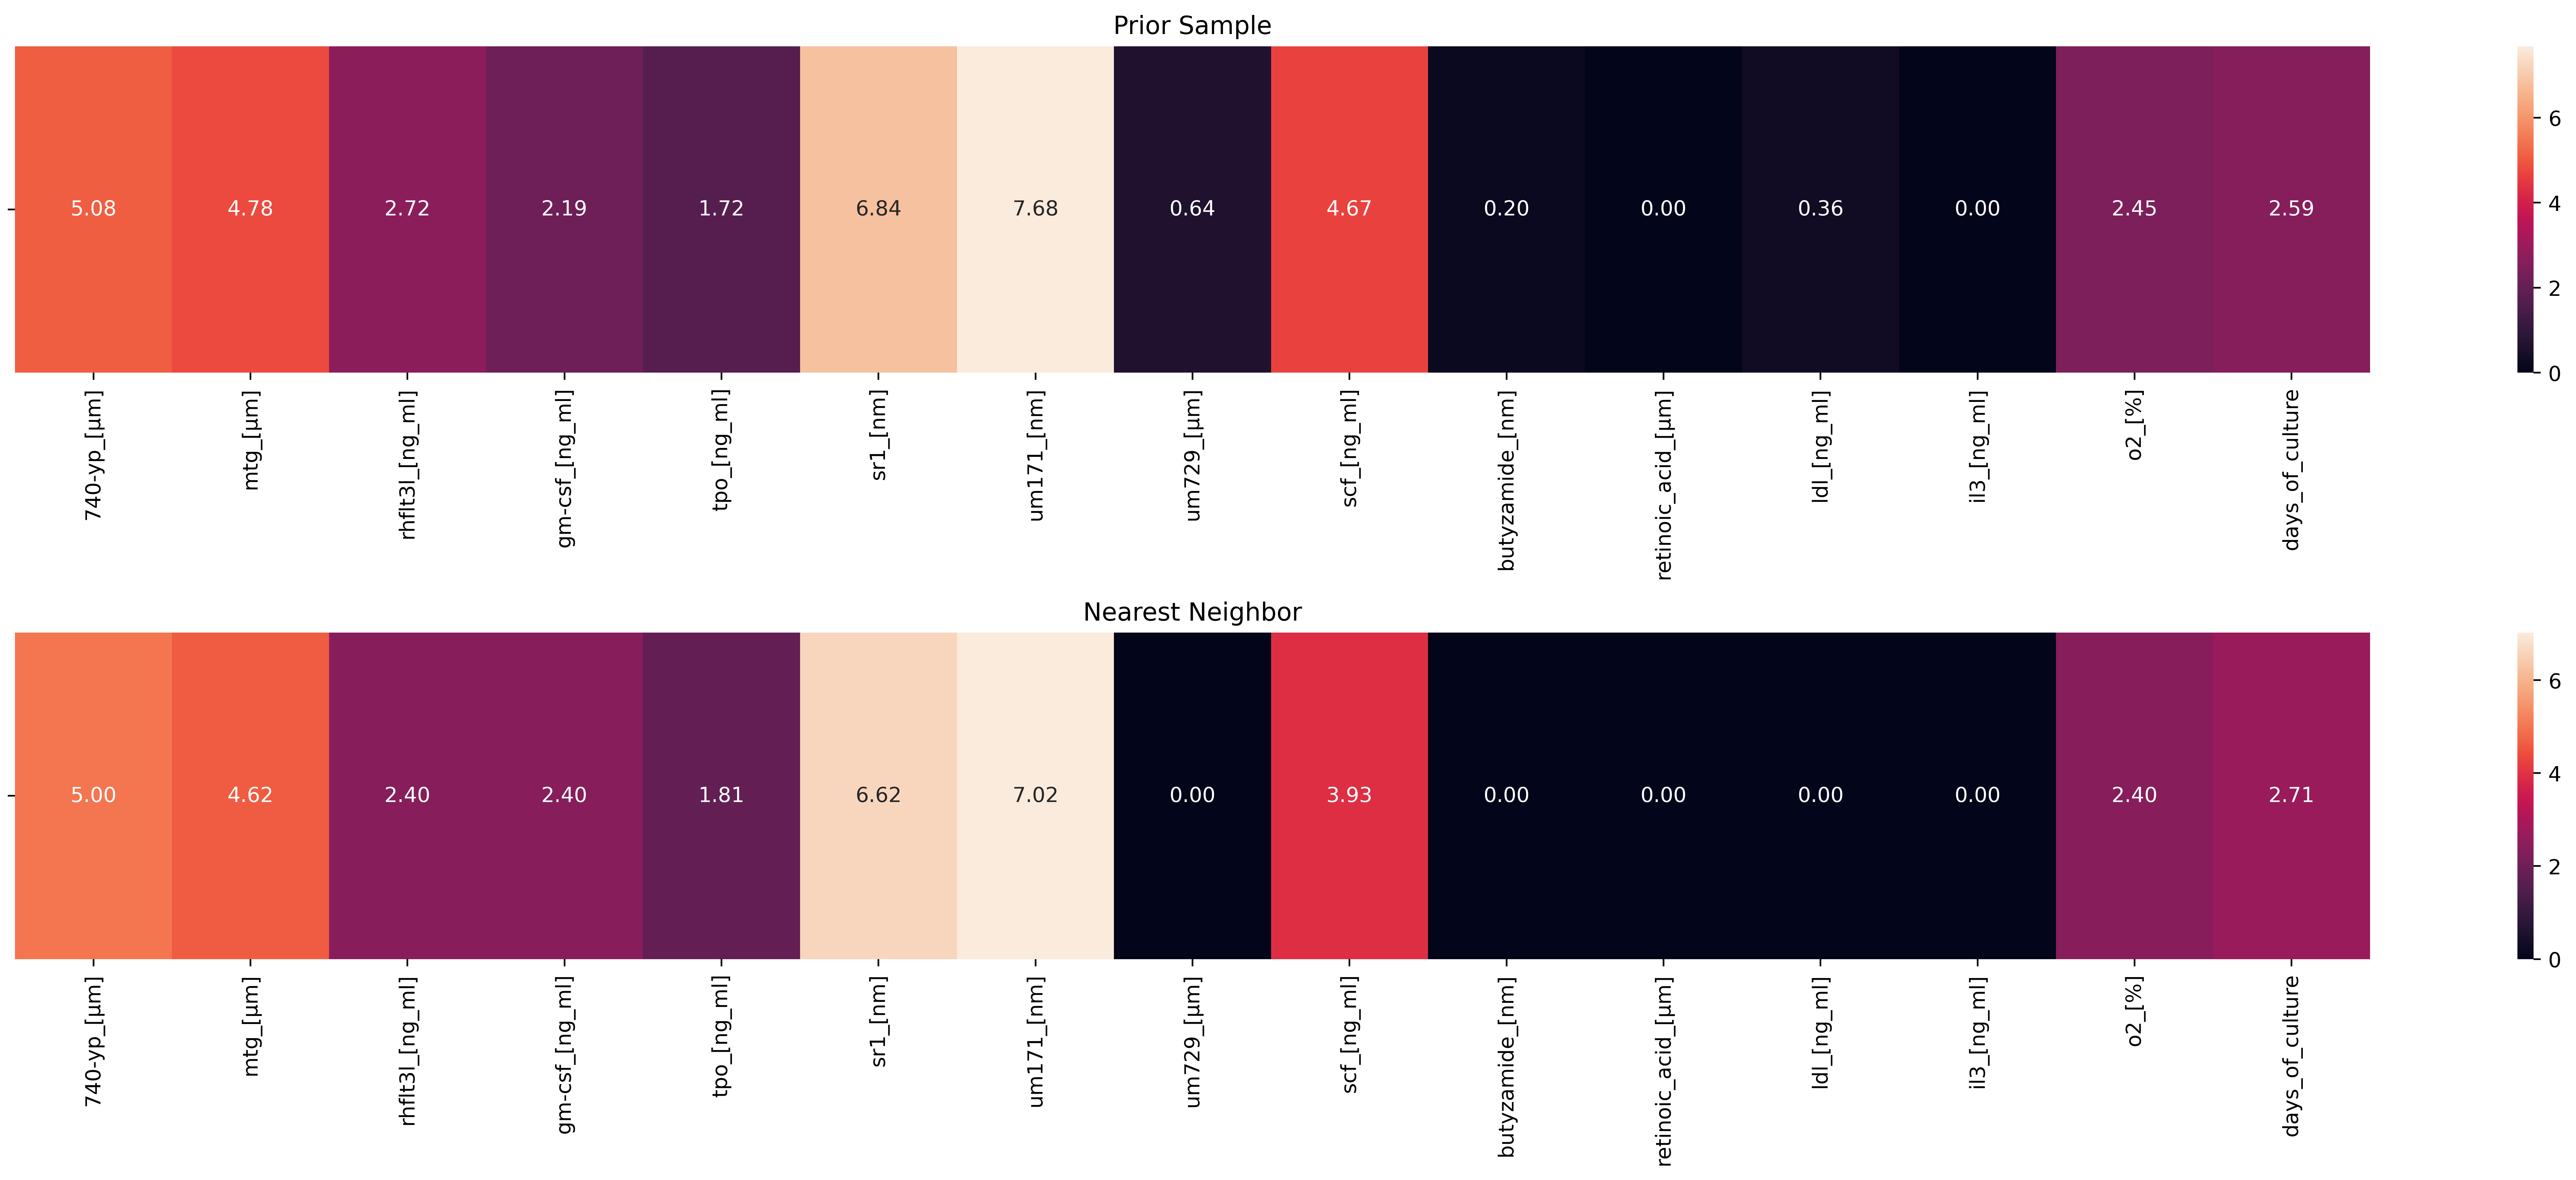

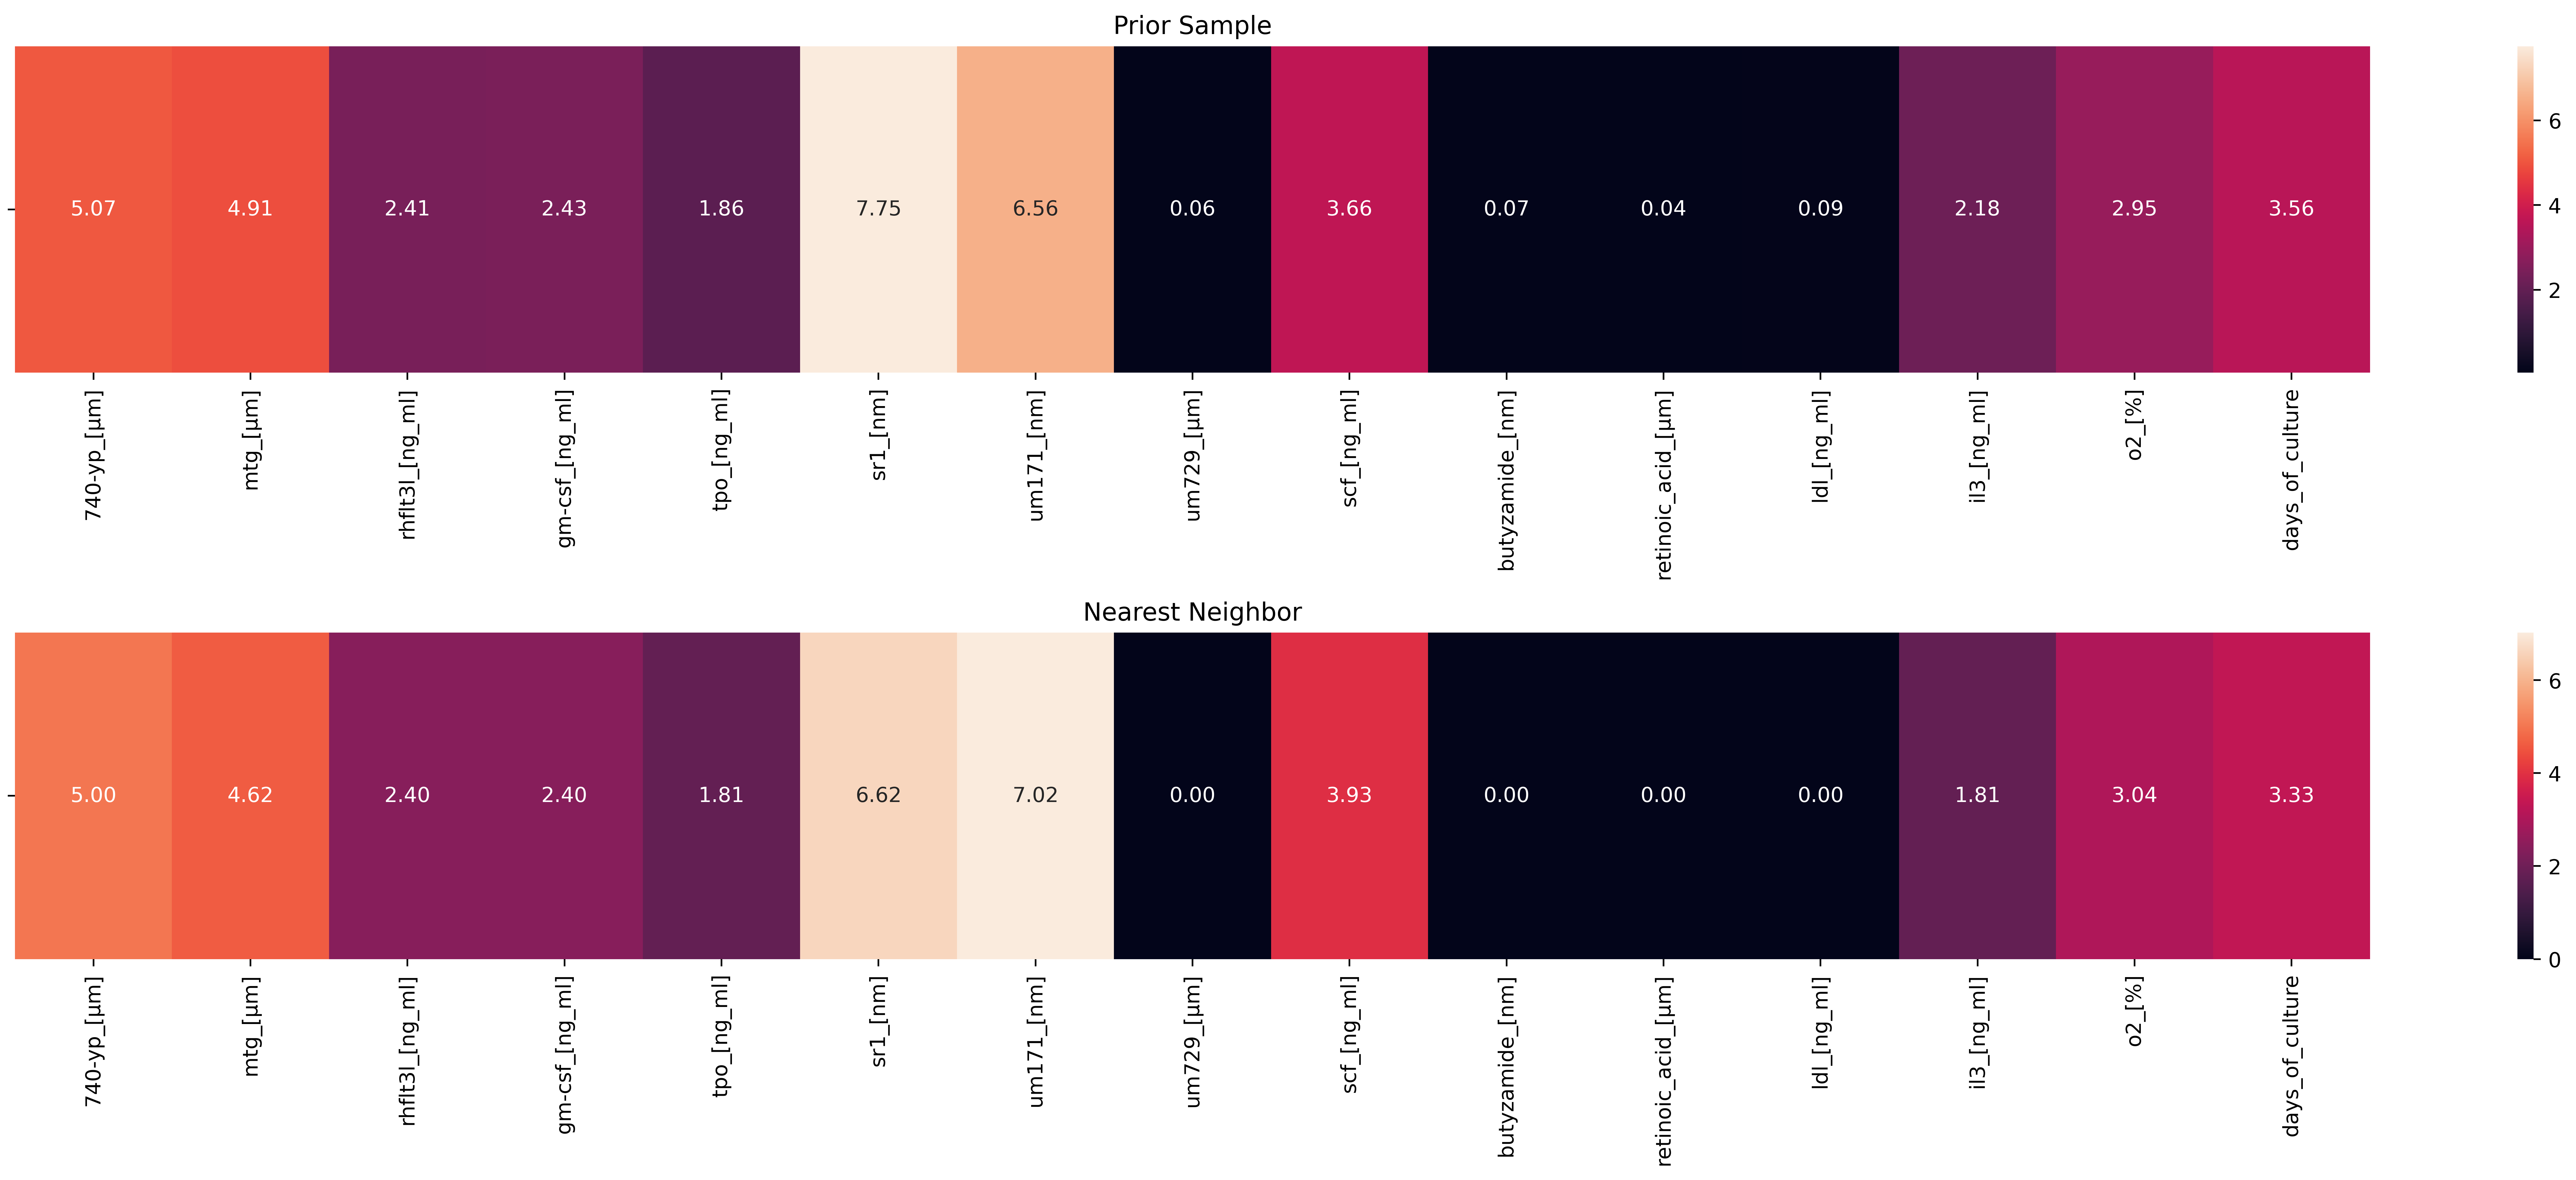

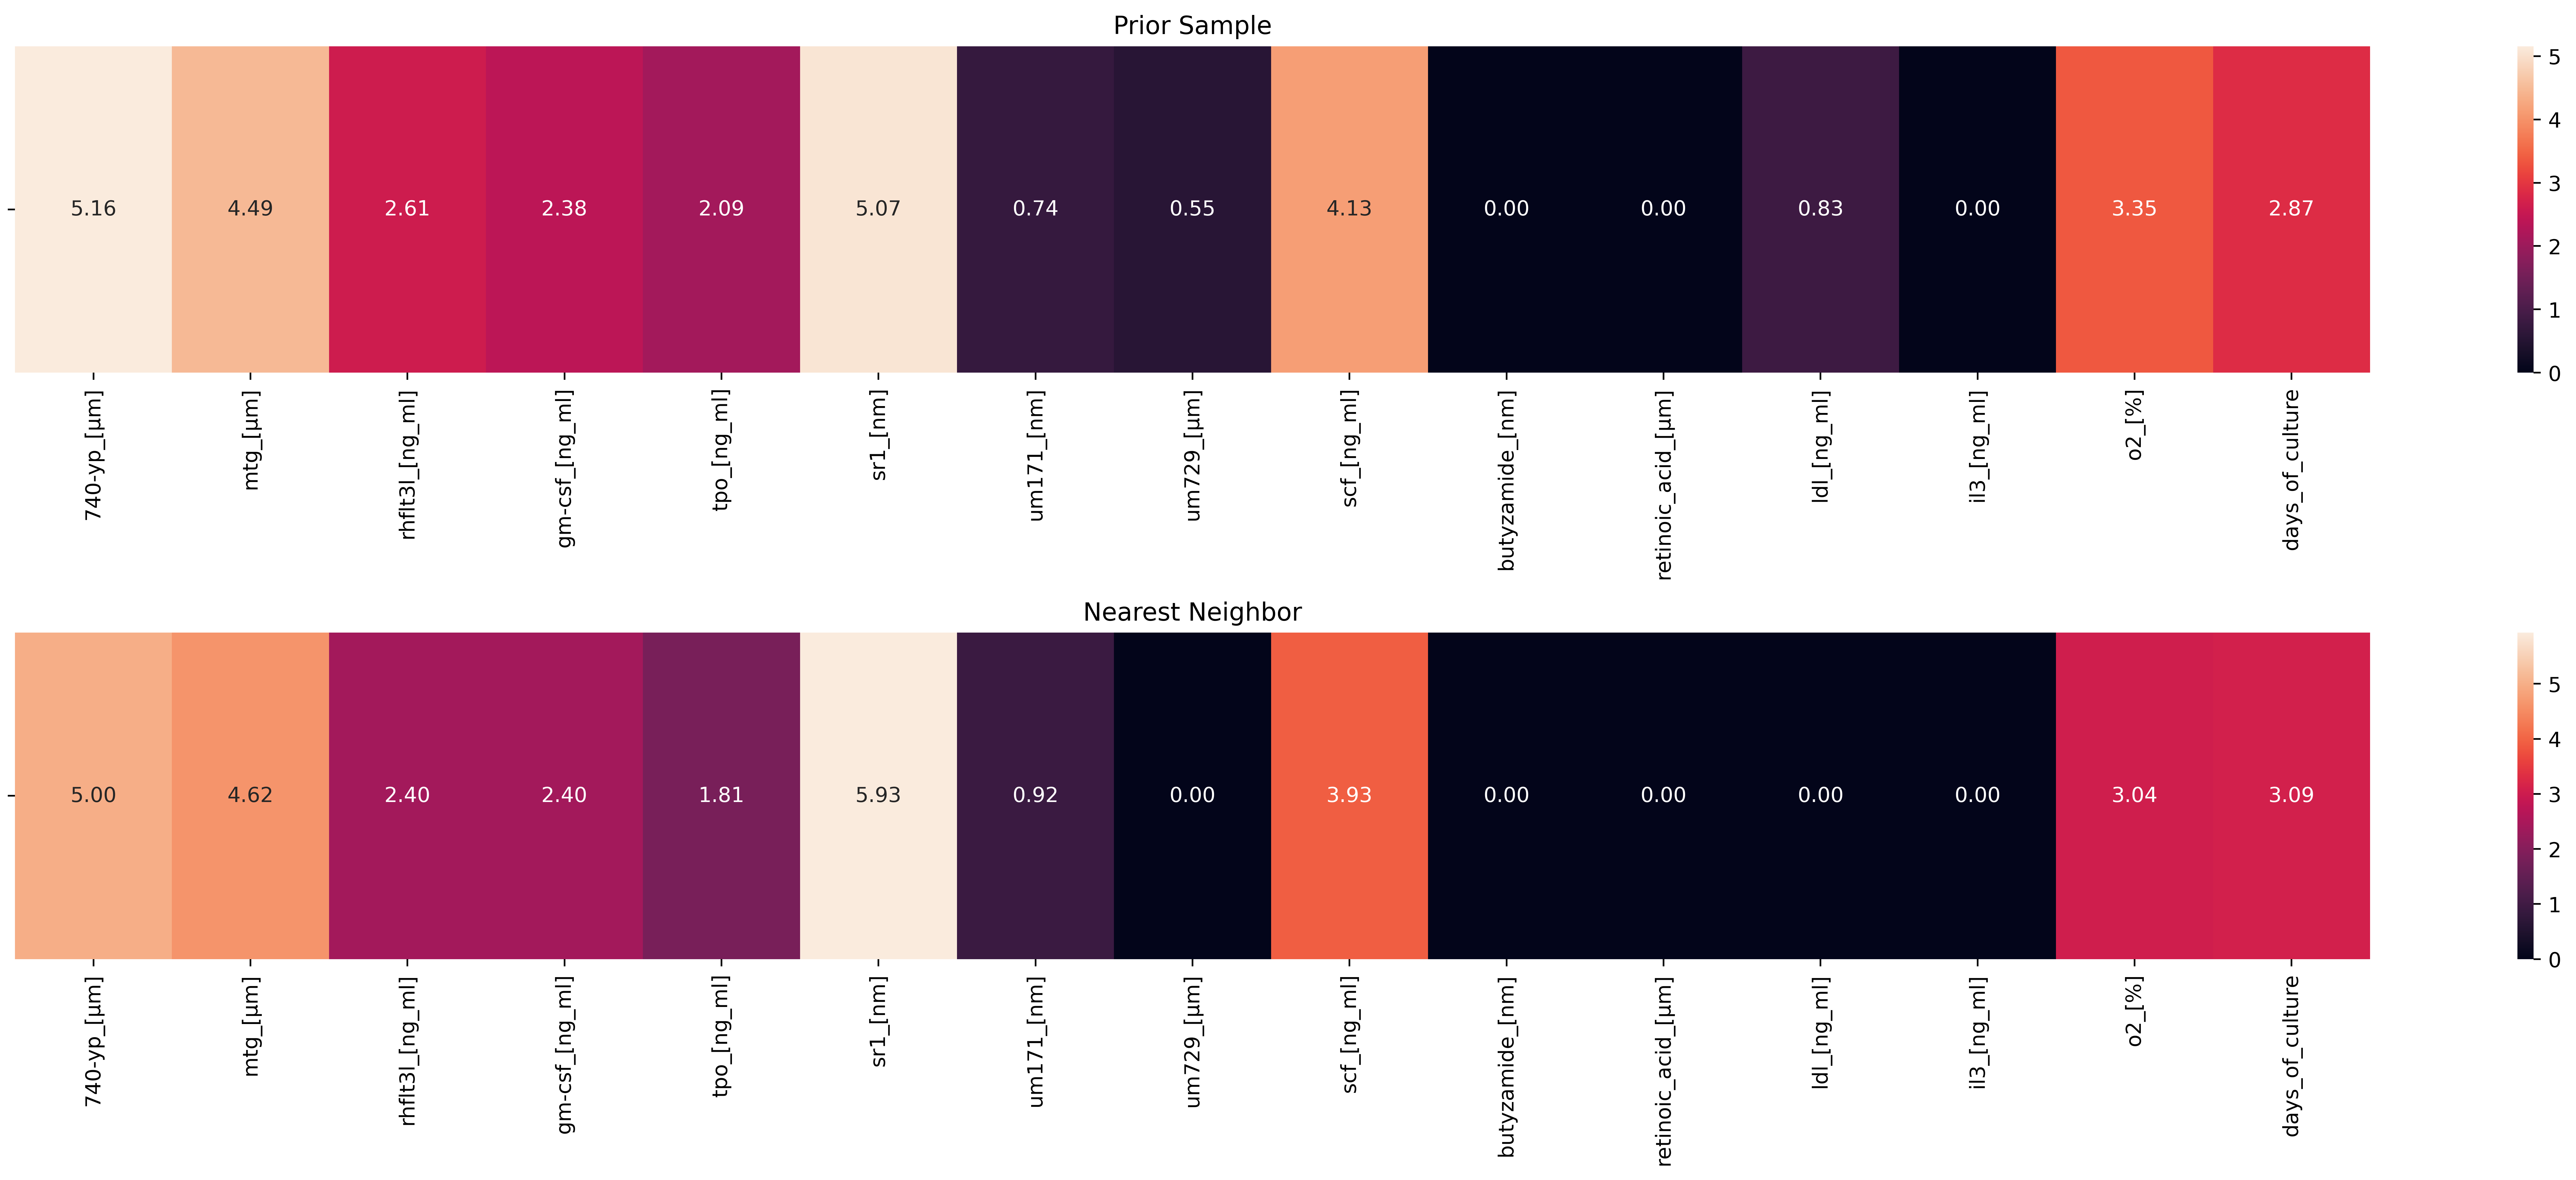

In [ ]:
for idx in cond2adata.keys():
    sample = prior_samples[idx][None]
    nn_val = nn_vals[idx][None]
    fig, ax = plt.subplots(2, 1, figsize=(20, 8), dpi=500)
    sns.heatmap(
        sample,
        annot=True,
        fmt=".2f",
        ax=ax[0],
        xticklabels=train_adata.var_names,
    )
    ax[0].set_title("Prior Sample")
    ax[0].set_yticklabels([])

    sns.heatmap(
        nn_val,
        annot=True,
        fmt=".2f",
        ax=ax[1],
        xticklabels=train_adata.var_names,
    )
    ax[1].set_title("Nearest Neighbor")
    ax[1].set_yticklabels([])
    fig.tight_layout()
    fig.show()

### Plotting the cells and highlighting generated ones.

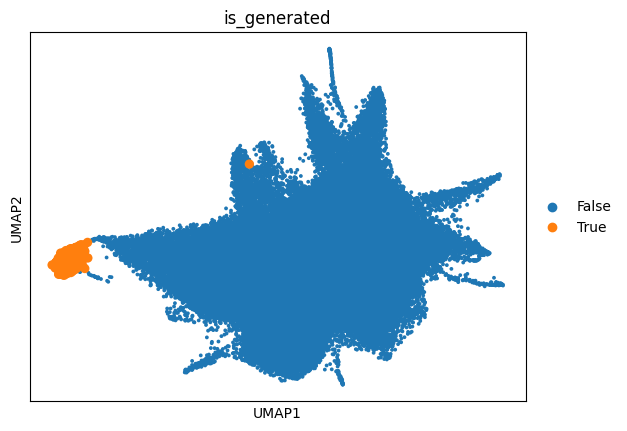

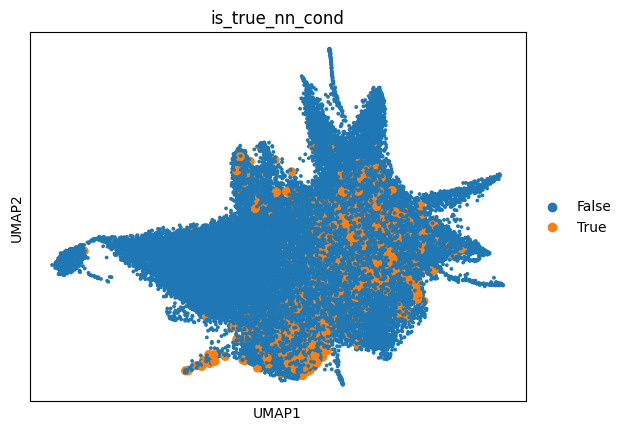

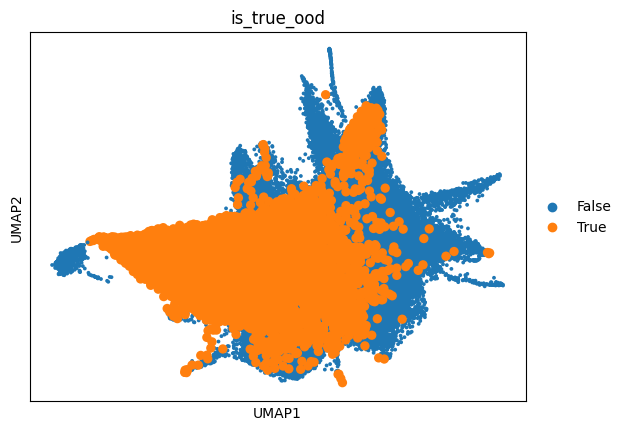

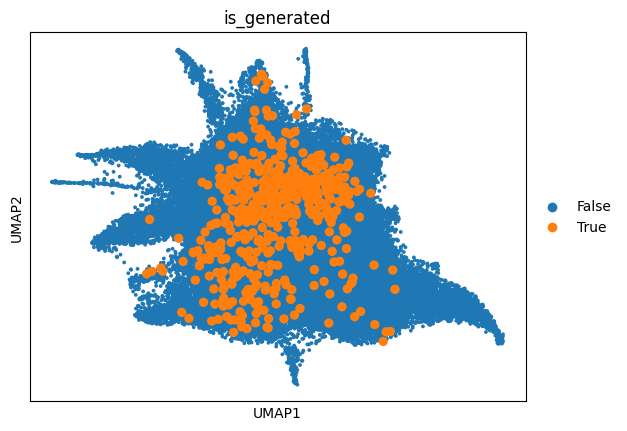

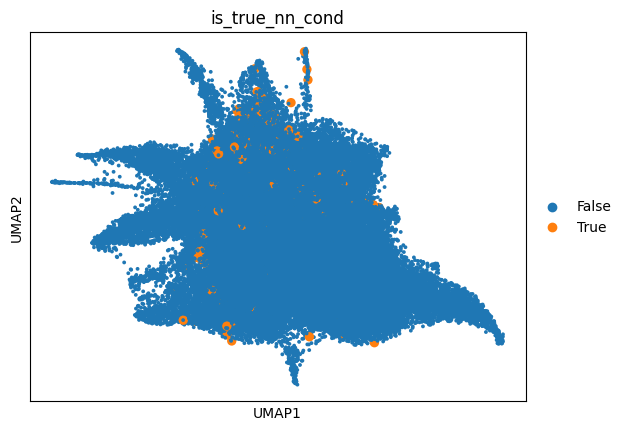

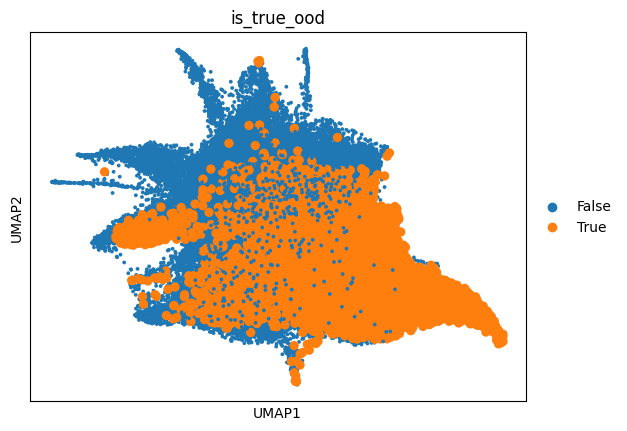

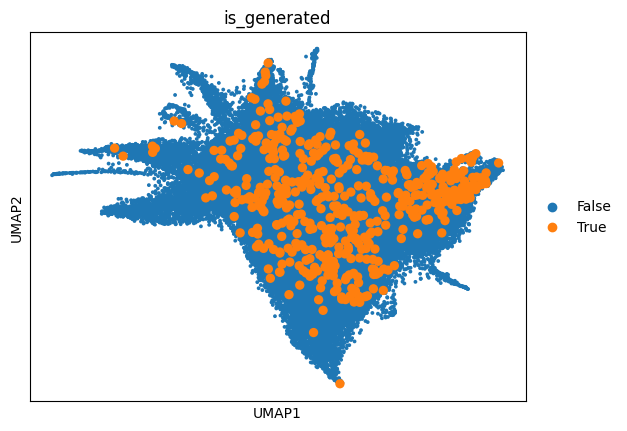

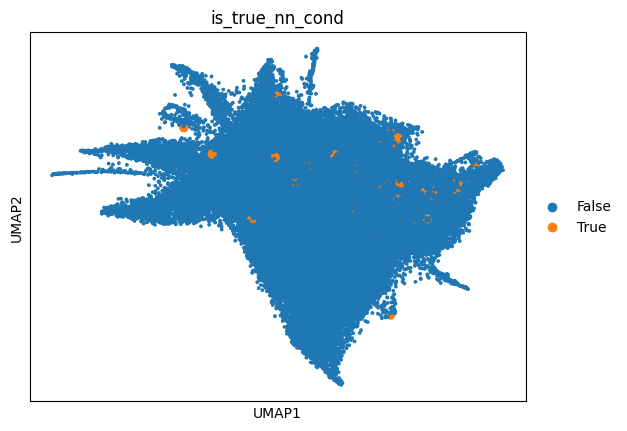

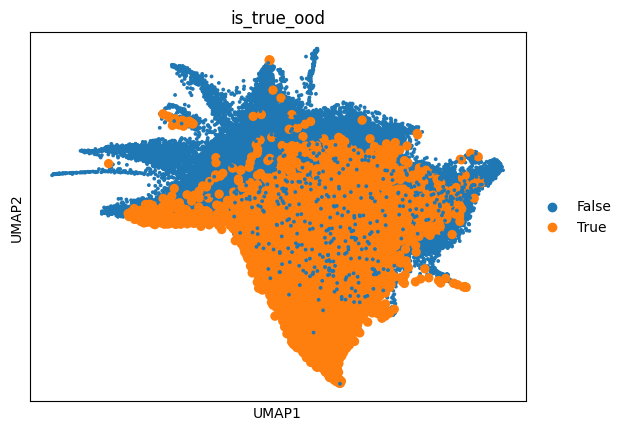

In [ ]:
base_size = 30
highlight_size = 180
base_alpha=1.0
highlight_alpha=1.0
for idx, adata in cond2adata.items():
    size=[base_size]*(n_train_cells + n_val_cells) + [highlight_size]*n_fwd_samples
    alpha=[base_alpha]*(n_train_cells + n_val_cells) + [highlight_alpha]*n_fwd_samples
    sc.pl.embedding(adata, "umap", size=size, alpha=alpha, color="is_generated")

    mask = adata.obs["is_true_nn_cond"].astype(int)
    size = mask*(highlight_size - base_size) + base_size
    alpha = mask*(highlight_alpha - base_alpha) + base_alpha
    sc.pl.embedding(adata, "umap", size=size, alpha=alpha, color="is_true_nn_cond")

    mask = adata.obs["is_true_ood"].astype(int)
    size = mask*(highlight_size - base_size) + base_size
    alpha = mask*(highlight_alpha - base_alpha) + base_alpha
    sc.pl.embedding(adata, "umap", size=size, alpha=alpha, color="is_true_ood")


## Inverse Model.

### Retrieving cell type composition from validationd data.

In [ ]:
X_val = torch.from_numpy(val_adata_fwd.obsm[cell_state_rep]).float().to(target_prediction_model.device)
target_prediction_model.target_prediction_model.eval()
with torch.no_grad():
    logits = target_prediction_model.predict(X_val)["cell_type"].detach().cpu().numpy()
del X_val
torch.cuda.empty_cache()
target_probs = softmax(logits, axis=1).mean(0)
print(target_probs)

[7.7521621e-04 2.6993057e-02 9.9678684e-05 1.2876993e-03 2.0781506e-02
 1.9725335e-03 2.6388891e-02 9.3988143e-03 2.2509208e-04 4.1620668e-02
 8.4201610e-03 1.1090161e-03 1.2324501e-01 2.4460016e-02 6.1987243e-03
 6.5758884e-01 9.3533490e-06 2.6340385e-03 4.6792001e-02]


### Initializing guided flow.

In [ ]:
N_FORWARD_PASS_PER_SAMPLE = 100
REGULARIZATION = None
REG_STRENGTH = 1e-2
loss_fns = {"cell_type":lambda pred, target:-torch.sum(target*torch.nn.functional.log_softmax(pred, dim=-1), dim=-1)}
guided_flow = LossGuidedFlow(
    prior_flow,
    forward_model,
    loss_fns,
    fix_noise=True,
    num_forward_pass_per_sample=N_FORWARD_PASS_PER_SAMPLE,
    regularization=REGULARIZATION,
    reg_strength=REG_STRENGTH,
)
non_linearity = torch.nn.ReLU()

### Initializing lambda scheduler.

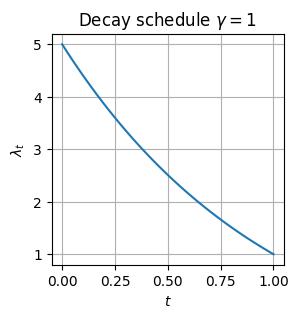

In [ ]:
LMAX = 5.0
LMIN = 1.0
GAMMA = 1

lambda_scheduler = ExponentialDecayScheduler(LMIN, LMAX, GAMMA)

# visualizing decaying scheduler
t = torch.linspace(0.0, 1.0, 100)
lambda_t = lambda_scheduler.compute_lambda_t(t)
plt.figure(figsize=(3, 3))
plt.plot(t, lambda_t)
plt.title(fr"Decay schedule $\gamma=${GAMMA}")
plt.xlabel(r"$t$")
plt.ylabel(r"$\lambda_t$")
plt.grid(True)



### Sampling from posterior.

In [ ]:
non_linearity

ReLU()

In [ ]:
SDE_SAMPLING = False
N_POSTERIOR_SAMPLES = 1_00
N_TIME_STEPS_POSTERIOR_MODEL = 30 if SDE_SAMPLING else 100
SOLVER_KWARGS_POSTERIOR_MODEL = {"method": "euler"}
seed = 42
set_reproducibility(seed)

traj, loss_history, lambda_history, noise = guided_flow.sample_posterior(
    N_POSTERIOR_SAMPLES,
    optimal_condition={
        "cell_type":torch.from_numpy(target_probs).unsqueeze(0).to(guided_flow.prior_flow.device)
    },
    num_time_steps=N_TIME_STEPS_POSTERIOR_MODEL,
    solver_kwargs=SOLVER_KWARGS_POSTERIOR_MODEL,
    lambda_scheduler=lambda_scheduler,
    non_linearity=non_linearity,
    sde_sampling=SDE_SAMPLING
)
if noise is not None:
    print(f"{traj.shape=}, {loss_history.shape=}, {lambda_history.shape=}, {noise.shape=}")
else:
    print(f"{traj.shape=}, {loss_history.shape=}, {lambda_history.shape=}")

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


traj.shape=(100, 100, 15), loss_history.shape=(100, 99), lambda_history.shape=(100, 99), noise.shape=torch.Size([100, 100, 27])


### Plotting Loss History.

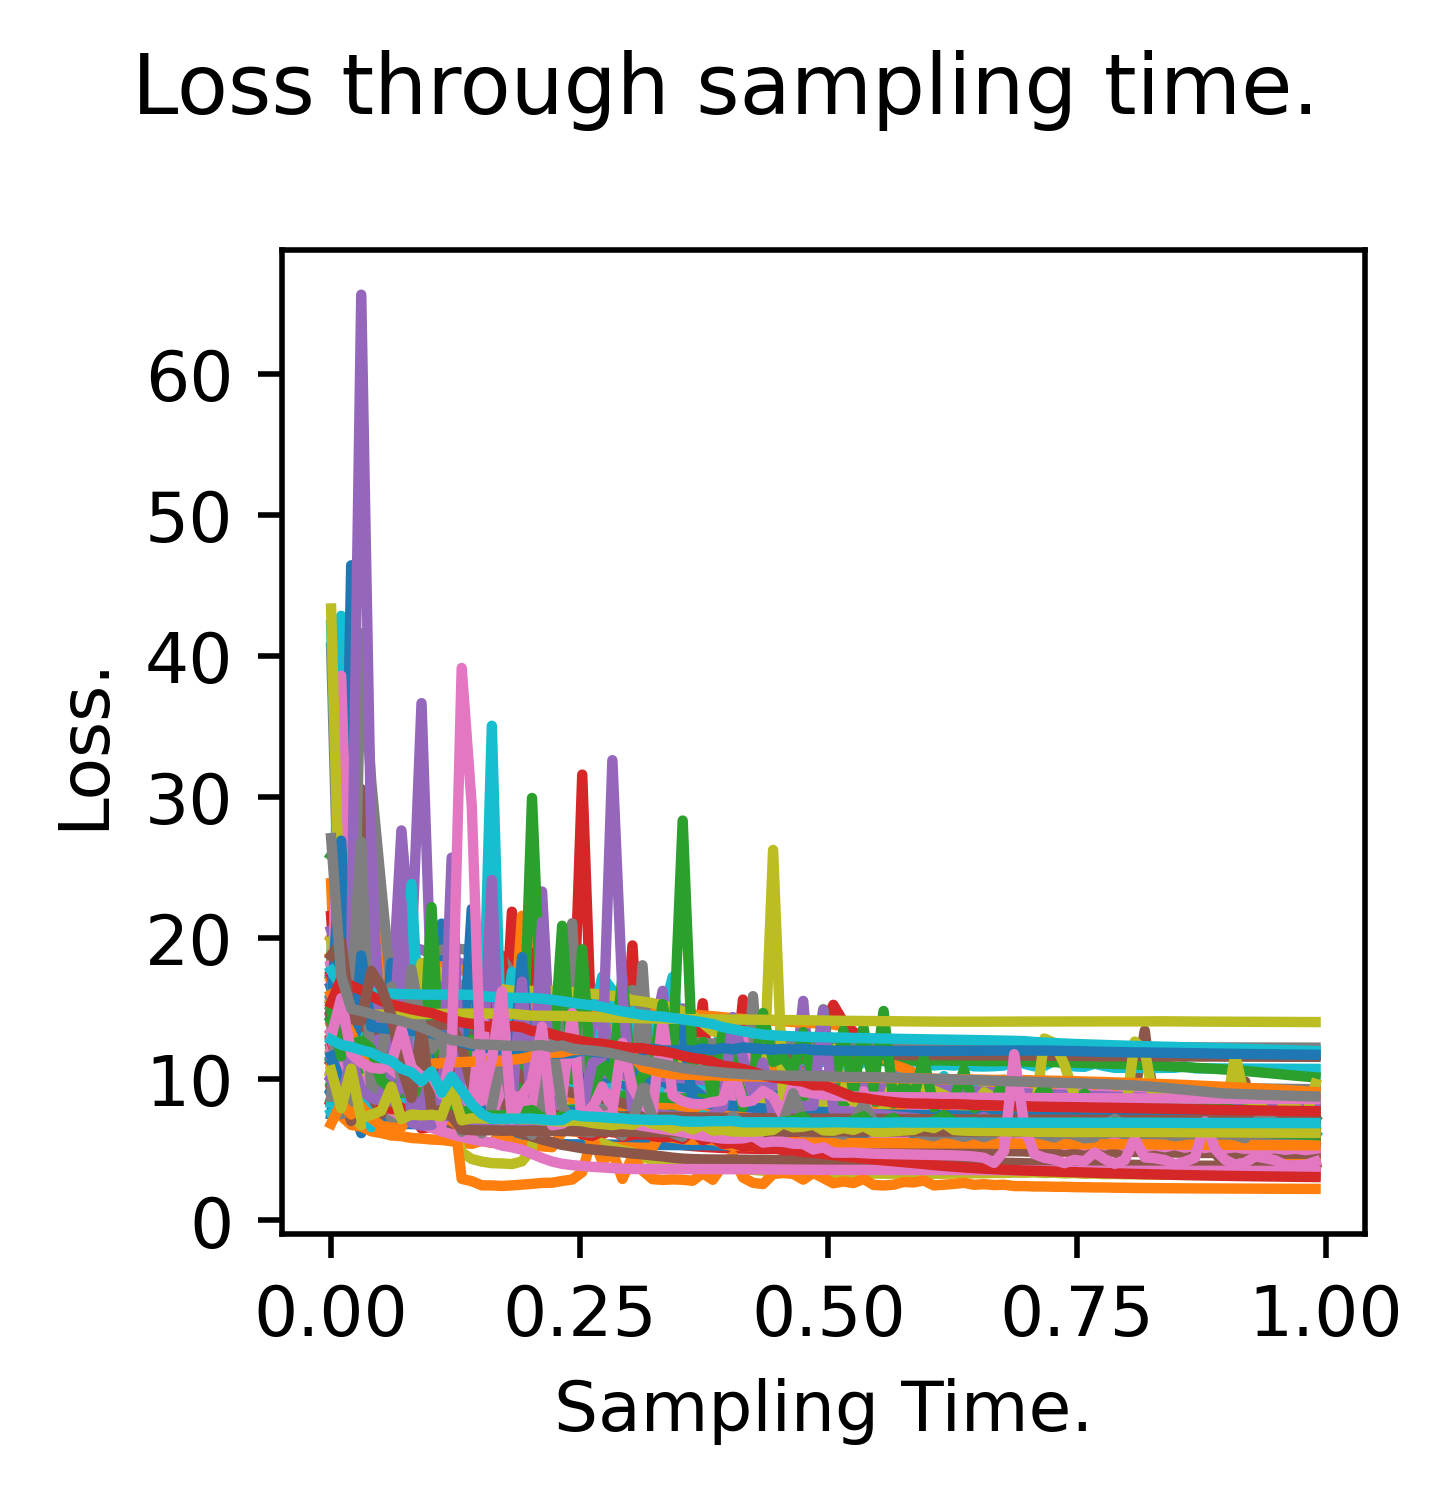

In [ ]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=500)
t = np.arange(0, 1, 1/loss_history.shape[1])
lines = ax.plot(t, loss_history.T)
fig.suptitle("Loss through sampling time.")
ax.set_xlabel("Sampling Time.")
ax.set_ylabel("Loss.")
fig.tight_layout(); fig.show()

### Comparing with ood protocol.

In [ ]:
sns.set_style("white")
sns.set_context("talk")  # poster-friendly font sizes

estar = val_adata_fwd.obsm[perturbation_id]

samples = np.maximum(traj[:, -1, :], 0)
emin_loss_idx = np.argmin(loss_history[:, -1])
min_samples = samples[emin_loss_idx][:, None]

fig, ax = plt.subplots(1, 3, figsize=(12, 3))  # slightly bigger for poster

xticks = train_adata.var_names

# Plot 1: samples (no annotations)
sns.heatmap(
    samples,
    annot=False,
    cbar=False,
    xticklabels=xticks,
    yticklabels=False,
    ax=ax[0]
)

# Plot 2: target (with annotations)
sns.heatmap(
    estar,
    annot=True,
    fmt=".2f",
    cbar=False,
    xticklabels=xticks,
    yticklabels=False,
    ax=ax[2]
)

# Plot 2: target (with annotations)
sns.heatmap(
    min_samples,
    annot=True,
    fmt=".2f",
    cbar=False,
    xticklabels=xticks,
    yticklabels=False,
    ax=ax[1]
)

# Format x-axis labels
for a in ax:
    a.tick_params(axis='x', labelsize=16)
    a.set_xticklabels(a.get_xticklabels(), rotation=45, ha="right")

fig.tight_layout(pad=2)
plt.show()